# Offspeed Scatters

In [1]:
import polars as pl
import numpy as np
import pandas as pd
from plotnine import *
import statsmodels.api as sm

In [2]:
(relievers := pl.read_parquet('data/statcast_relievers.parquet')).head(3)

pitcher_id,date,game_id,velocity,spin_rate,pitch_type_abbr,pitch_type,pitch_result,ab_result,pitch_call,strike_zone,ball_count,strike_count,outs,inning,top_bottom,home_team,away_team,ab_number,pitch_num,batted_ball_type,runner_1b,runner_2b,runner_3b,away_score,home_score,defense_score,offense_score,game_type,batter_side,pitcher_hand,pitcher_days_since_prev_game,pitcher_days_until_next_game,year,pitcher_name
i64,datetime[ns],i64,f64,i64,str,str,str,str,str,i64,i64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i32,str
433589,2021-04-01 00:00:00,634640,85.8,1989,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",41,1,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.5,2182,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",12,0,0,1,6,"""Top""","""ATH""","""HOU""",39,1,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,85.6,2136,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",40,1,null,663656,608324,null,1,0,0,1,"""R""","""L""","""R""",null,3,2021,"""Yusmeiro Petit"""


In [3]:
(outing_table := pl.read_parquet('data/outing_table.parquet')).head(3)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124


In [4]:
(complete_outing_table := pl.read_parquet('data/complete_outing_table.parquet')).head(3)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct,season_avg_strike_pct,strike_pct_deviation,first_pitch_strike_pct,season_avg_fp_strike_pct,fp_strike_pct_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20""",1.524306,0.5625,0.675712,-0.113212,0.25,0.633114,-0.383114
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6,0.675712,-0.075712,0.333333,0.633114,-0.299781
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,null,10,26,26,26,26,-0.313921,1.491772,0.000171,0.063228,"""≤10""","""≤10""",0.478473,0.875,0.675712,0.199288,1.0,0.633114,0.366886


In [5]:
relievers["pitch_type_abbr"].unique().to_list()

['SC',
 'FF',
 'CU',
 'PO',
 'FA',
 'ST',
 'FS',
 'SV',
 'SI',
 'KC',
 'CS',
 'CH',
 None,
 'SL',
 'FC']

In [6]:
relievers["pitch_type"].unique().to_list()

['Split-Finger',
 'Pitch Out',
 'Slow Curve',
 'Curveball',
 'Sweeper',
 'Other',
 '4-Seam Fastball',
 'Screwball',
 None,
 'Sinker',
 'Slurve',
 'Knuckle Curve',
 'Slider',
 'Cutter',
 'Changeup']

In [7]:
breaking_types = ["SL", "ST", "SV", "CU", "KC", "SC", "CS"]   # sliders + curves
offspeed_types = ["CH", "FS"]                                # changeup + splitter
min_family_pitches = 5                                       # reduce noise (tune 3–8)

In [8]:
(breaking_outings := (
    relievers
    .filter(pl.col("pitch_type_abbr").is_in(breaking_types))
    .drop_nulls(["velocity", "spin_rate", "pitcher_id", "game_id", "year"])
    .group_by(["pitcher_id", "game_id", "year"])
    .agg([
        pl.mean("velocity").alias("mean_break_velo"),
        pl.mean("spin_rate").alias("mean_break_spin"),
        pl.len().alias("break_pitch_count"),
    ])
    .filter(pl.col("break_pitch_count") >= min_family_pitches)
    .with_columns([
        pl.col("mean_break_velo").mean().over(["pitcher_id", "year"]).alias("season_avg_break_velo"),
        pl.col("mean_break_spin").mean().over(["pitcher_id", "year"]).alias("season_avg_break_spin"),
    ])
    .with_columns([
        (pl.col("mean_break_velo") - pl.col("season_avg_break_velo")).alias("break_velo_deviation"),
        (pl.col("mean_break_spin") - pl.col("season_avg_break_spin")).alias("break_spin_deviation"),
    ])
))

pitcher_id,game_id,year,mean_break_velo,mean_break_spin,break_pitch_count,season_avg_break_velo,season_avg_break_spin,break_velo_deviation,break_spin_deviation
i64,i64,i32,f64,f64,u32,f64,f64,f64,f64
657044,661326,2022,78.414286,2067.0,7,79.522577,2156.645113,-1.108291,-89.645113
612434,633100,2021,83.777778,3056.111111,9,85.729107,2982.856938,-1.951329,73.254173
621366,717166,2023,86.869231,2368.615385,13,86.625261,2421.386185,0.24397,-52.770801
598264,634574,2021,85.683333,2243.0,6,85.322619,2120.946052,0.360714,122.053948
543766,717088,2023,82.913333,2438.866667,15,82.763616,2459.234466,0.149717,-20.3678
…,…,…,…,…,…,…,…,…,…
600986,745998,2024,89.25,2300.055556,18,88.556016,2294.516856,0.693984,5.538699
502085,746174,2024,84.085714,2829.857143,7,84.024625,2712.444655,0.061089,117.412488
523260,633199,2021,88.091667,2885.75,12,87.189551,2893.317441,0.902116,-7.567441


In [9]:
(offspeed_outings := (
    relievers
    .filter(pl.col("pitch_type_abbr").is_in(offspeed_types))
    .drop_nulls(["velocity", "spin_rate", "pitcher_id", "game_id", "year"])
    .group_by(["pitcher_id", "game_id", "year"])
    .agg([
        pl.mean("velocity").alias("mean_off_velo"),
        pl.mean("spin_rate").alias("mean_off_spin"),
        pl.len().alias("off_pitch_count"),
    ])
    .filter(pl.col("off_pitch_count") >= min_family_pitches)
    .with_columns([
        pl.col("mean_off_velo").mean().over(["pitcher_id", "year"]).alias("season_avg_off_velo"),
        pl.col("mean_off_spin").mean().over(["pitcher_id", "year"]).alias("season_avg_off_spin"),
    ])
    .with_columns([
        (pl.col("mean_off_velo") - pl.col("season_avg_off_velo")).alias("off_velo_deviation"),
        (pl.col("mean_off_spin") - pl.col("season_avg_off_spin")).alias("off_spin_deviation"),
    ])
)).head(5)

pitcher_id,game_id,year,mean_off_velo,mean_off_spin,off_pitch_count,season_avg_off_velo,season_avg_off_spin,off_velo_deviation,off_spin_deviation
i64,i64,i32,f64,f64,u32,f64,f64,f64,f64
681869,746374,2024,88.185714,1619.142857,7,88.156257,1595.477766,0.029457,23.665091
608717,662385,2022,87.3,2285.5,6,87.3,2285.5,0.0,0.0
641871,717925,2023,86.5,1974.2,5,87.747098,1882.715935,-1.247098,91.484065
642083,633985,2021,86.76,1675.0,5,86.847273,1647.690909,-0.087273,27.309091
669211,747003,2024,86.166667,2066.833333,6,85.824825,2062.414881,0.341841,4.418452


In [10]:
(complete_outing_table_breaking := (
    complete_outing_table
    .join(
        breaking_outings,
        on=["pitcher_id", "game_id", "year"],
        how="left"
    )
))

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct,season_avg_strike_pct,strike_pct_deviation,first_pitch_strike_pct,season_avg_fp_strike_pct,fp_strike_pct_deviation,mean_break_velo,mean_break_spin,break_pitch_count,season_avg_break_velo,season_avg_break_spin,break_velo_deviation,break_spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20""",1.524306,0.5625,0.675712,-0.113212,0.25,0.633114,-0.383114,null,null,null,null,null,null,null
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6,0.675712,-0.075712,0.333333,0.633114,-0.299781,null,null,null,null,null,null,null
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,null,10,26,26,26,26,-0.313921,1.491772,0.000171,0.063228,"""≤10""","""≤10""",0.478473,0.875,0.675712,0.199288,1.0,0.633114,0.366886,null,null,null,null,null,null,null
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,null,null,8,8,18,34,-0.313921,1.491772,0.133921,0.056799,"""≤10""","""≤10""",0.25883,0.6,0.675712,-0.075712,0.5,0.633114,-0.133114,null,null,null,null,null,null,null
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,10,10,10,18,18,28,-0.313921,1.491772,0.226421,-0.129272,"""≤10""","""≤10""",0.084027,0.666667,0.675712,-0.009045,0.0,0.633114,-0.633114,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,746985,2024-09-19 00:00:00,2024,"""Spencer Bivens""",32,94.1,97.5,2093.96875,-0.650938,0.590938,8,"""R""",-1,4,37,13,94.048879,1941.835625,0.051121,152.133125,null,null,null,13,13,13,-1.036227,0.51891,0.38529,0.072027,"""11-20""","""31+""",0.051121,0.621622,0.655255,-0.033633,0.5,0.637626,-0.137626,null,null,null,null,null,null,null
702352,746255,2024-09-21 00:00:00,2024,"""Spencer Bivens""",18,95.127778,97.2,2105.0,-0.842222,0.501667,7,"""R""",9,2,28,37,94.048879,1941.835625,1.078899,163.164375,null,37,37,37,37,50,-1.036227,0.51891,0.194005,-0.017243,"""31+""","""21-30""",1.078899,0.678571,0.655255,0.023316,0.75,0.637626,0.112374,82.6125,2349.5,8,81.050578,2217.623799,1.561922,131.876201
702352,747150,2024-09-23 00:00:00,2024,"""Spencer Bivens""",14,94.907143,97.1,2092.5,-0.977857,0.445714,6,"""R""",3,2,21,28,94.048879,1941.835625,0.858264,150.664375,null,28,28,65,65,65,-1.036227,0.51891,0.05837,-0.073196,"""21-30""","""21-30""",0.858264,0.619048,0.655255,-0.036207,0.5,0.637626,-0.137626,null,null,null,null,null,null,null


In [11]:
(complete_outing_table_offspeed := (
    complete_outing_table
    .join(
        offspeed_outings.select([
            "pitcher_id",
            "game_id",
            "year",
            "off_pitch_count",
            "off_velo_deviation",
            "off_spin_deviation"
        ]),
        on=["pitcher_id", "game_id", "year"],
        how="left"
    )
))

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct,season_avg_strike_pct,strike_pct_deviation,first_pitch_strike_pct,season_avg_fp_strike_pct,fp_strike_pct_deviation,off_pitch_count,off_velo_deviation,off_spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20""",1.524306,0.5625,0.675712,-0.113212,0.25,0.633114,-0.383114,null,null,null
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6,0.675712,-0.075712,0.333333,0.633114,-0.299781,null,null,null
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,null,10,26,26,26,26,-0.313921,1.491772,0.000171,0.063228,"""≤10""","""≤10""",0.478473,0.875,0.675712,0.199288,1.0,0.633114,0.366886,null,null,null
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,null,null,8,8,18,34,-0.313921,1.491772,0.133921,0.056799,"""≤10""","""≤10""",0.25883,0.6,0.675712,-0.075712,0.5,0.633114,-0.133114,null,null,null
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,10,10,10,18,18,28,-0.313921,1.491772,0.226421,-0.129272,"""≤10""","""≤10""",0.084027,0.666667,0.675712,-0.009045,0.0,0.633114,-0.633114,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,746985,2024-09-19 00:00:00,2024,"""Spencer Bivens""",32,94.1,97.5,2093.96875,-0.650938,0.590938,8,"""R""",-1,4,37,13,94.048879,1941.835625,0.051121,152.133125,null,null,null,13,13,13,-1.036227,0.51891,0.38529,0.072027,"""11-20""","""31+""",0.051121,0.621622,0.655255,-0.033633,0.5,0.637626,-0.137626,null,null,null
702352,746255,2024-09-21 00:00:00,2024,"""Spencer Bivens""",18,95.127778,97.2,2105.0,-0.842222,0.501667,7,"""R""",9,2,28,37,94.048879,1941.835625,1.078899,163.164375,null,37,37,37,37,50,-1.036227,0.51891,0.194005,-0.017243,"""31+""","""21-30""",1.078899,0.678571,0.655255,0.023316,0.75,0.637626,0.112374,null,null,null
702352,747150,2024-09-23 00:00:00,2024,"""Spencer Bivens""",14,94.907143,97.1,2092.5,-0.977857,0.445714,6,"""R""",3,2,21,28,94.048879,1941.835625,0.858264,150.664375,null,28,28,65,65,65,-1.036227,0.51891,0.05837,-0.073196,"""21-30""","""21-30""",0.858264,0.619048,0.655255,-0.036207,0.5,0.637626,-0.137626,null,null,null


## Breaking Pitches 

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 16351 rows containing missing values.


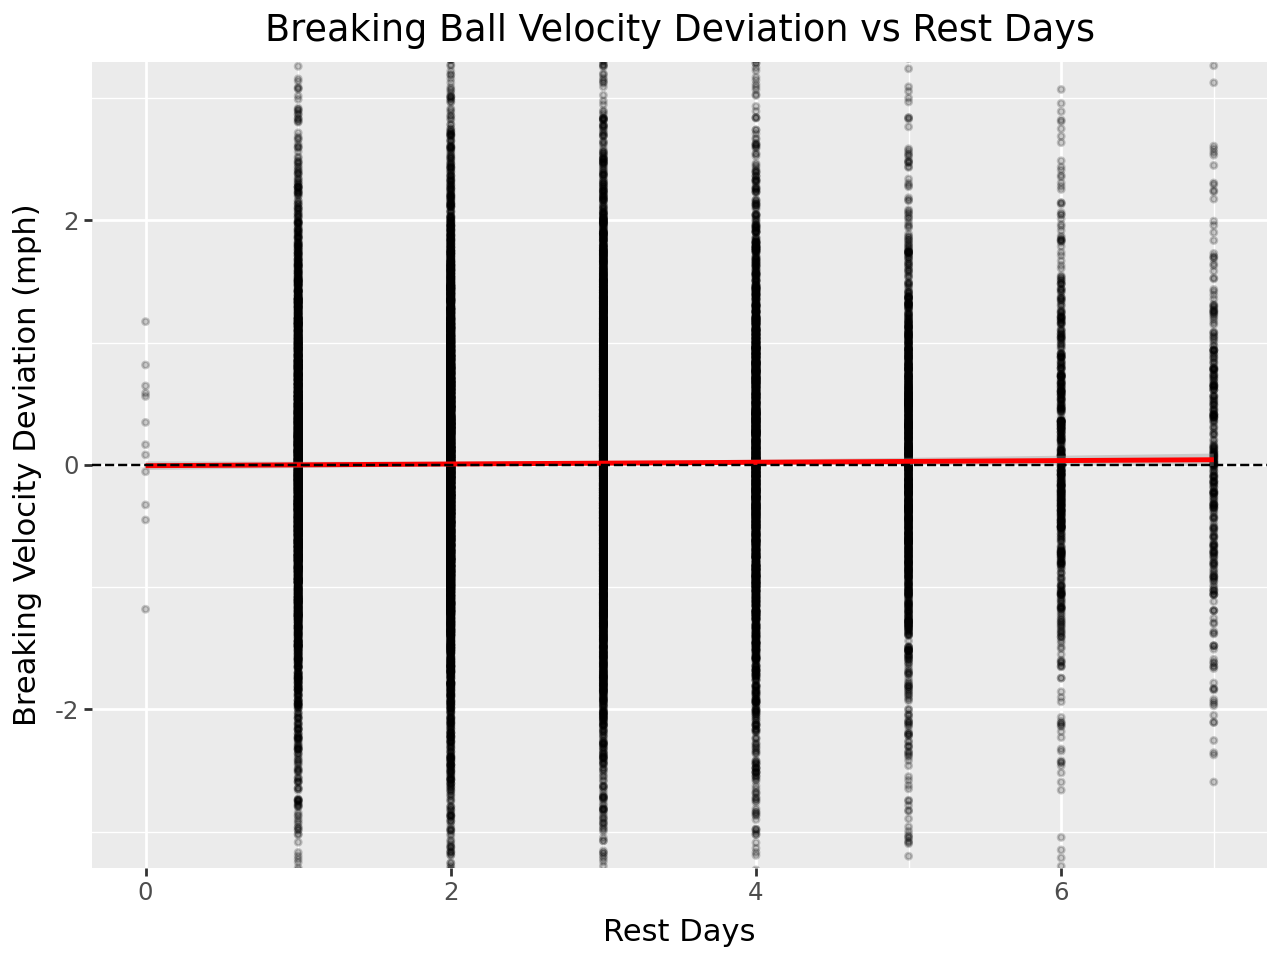

In [12]:
(
    ggplot(complete_outing_table_breaking, aes(x="rest_days", y="break_velo_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-3, 3)) +
    labs(
        title="Breaking Ball Velocity Deviation vs Rest Days",
        x="Rest Days",
        y="Breaking Velocity Deviation (mph)"
    )
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 16351 rows containing missing values.


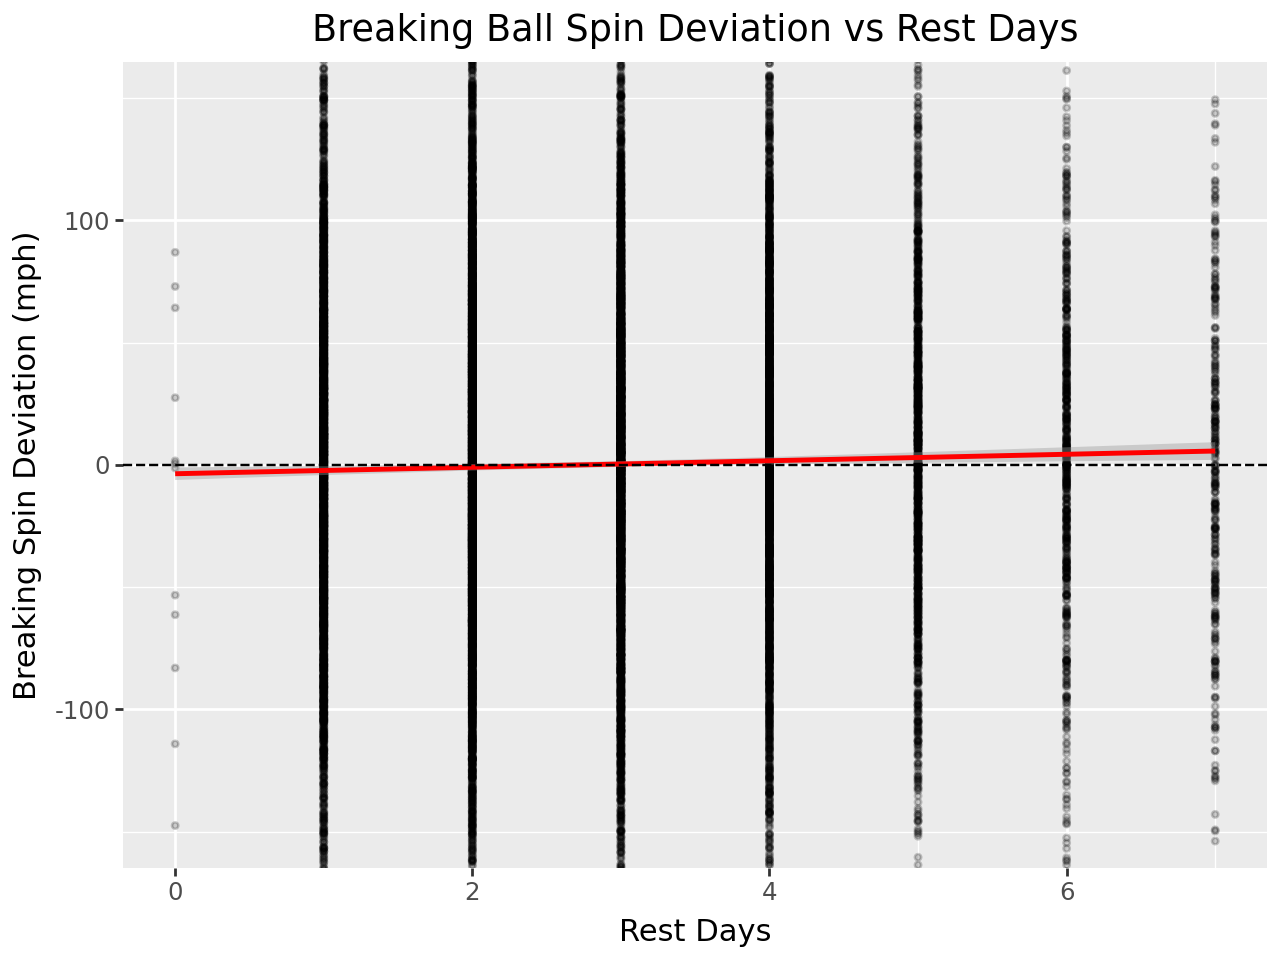

In [13]:
(
    ggplot(complete_outing_table_breaking, aes(x="rest_days", y="break_spin_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-150, 150)) +
    labs(
        title="Breaking Ball Spin Deviation vs Rest Days",
        x="Rest Days",
        y="Breaking Spin Deviation (mph)"
    )
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 16351 rows containing missing values.


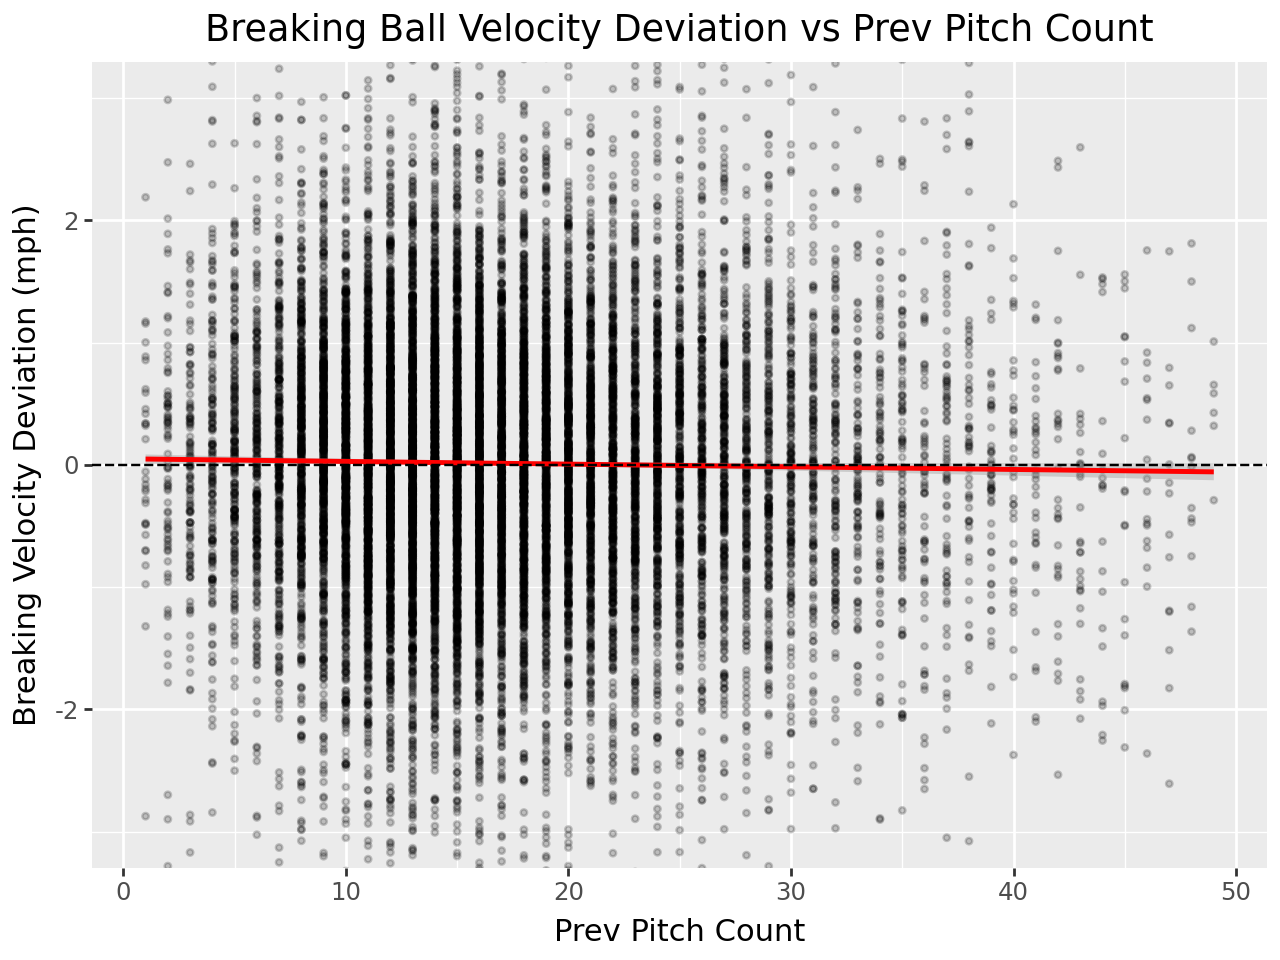

In [14]:
(
    ggplot(complete_outing_table_breaking, aes(x="prev_pitch_count", y="break_velo_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-3, 3)) +
    labs(
        title="Breaking Ball Velocity Deviation vs Prev Pitch Count",
        x="Prev Pitch Count",
        y="Breaking Velocity Deviation (mph)"
    )
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 16351 rows containing missing values.


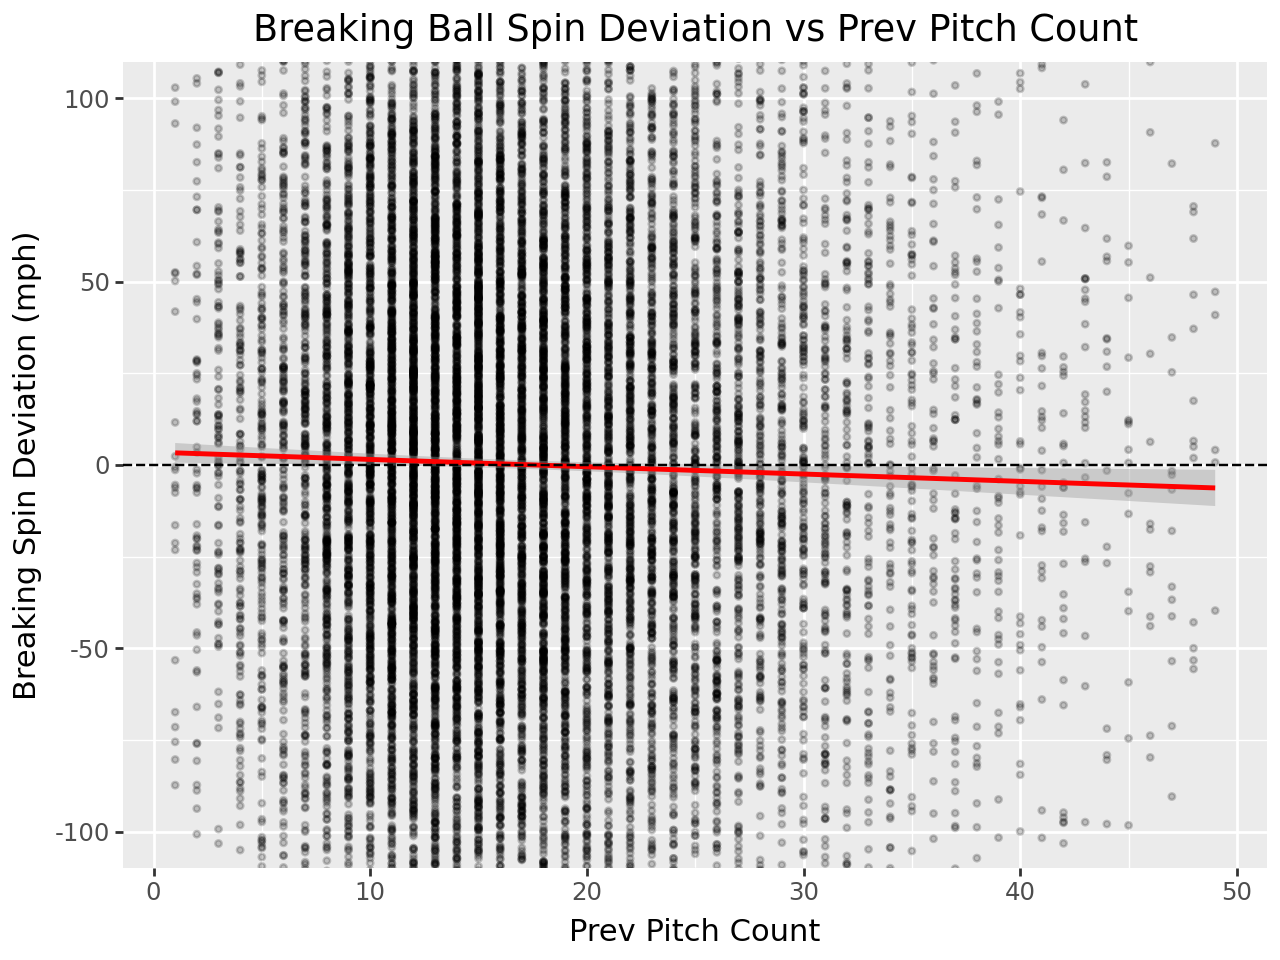

In [15]:
(
    ggplot(complete_outing_table_breaking, aes(x="prev_pitch_count", y="break_spin_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-100, 100)) +
    labs(
        title="Breaking Ball Spin Deviation vs Prev Pitch Count",
        x="Prev Pitch Count",
        y="Breaking Spin Deviation (mph)"
    )
)

prev pitch bin/models

C:\Users\kh6102sj\AppData\Local\Temp\ipykernel_7268\3432518238.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


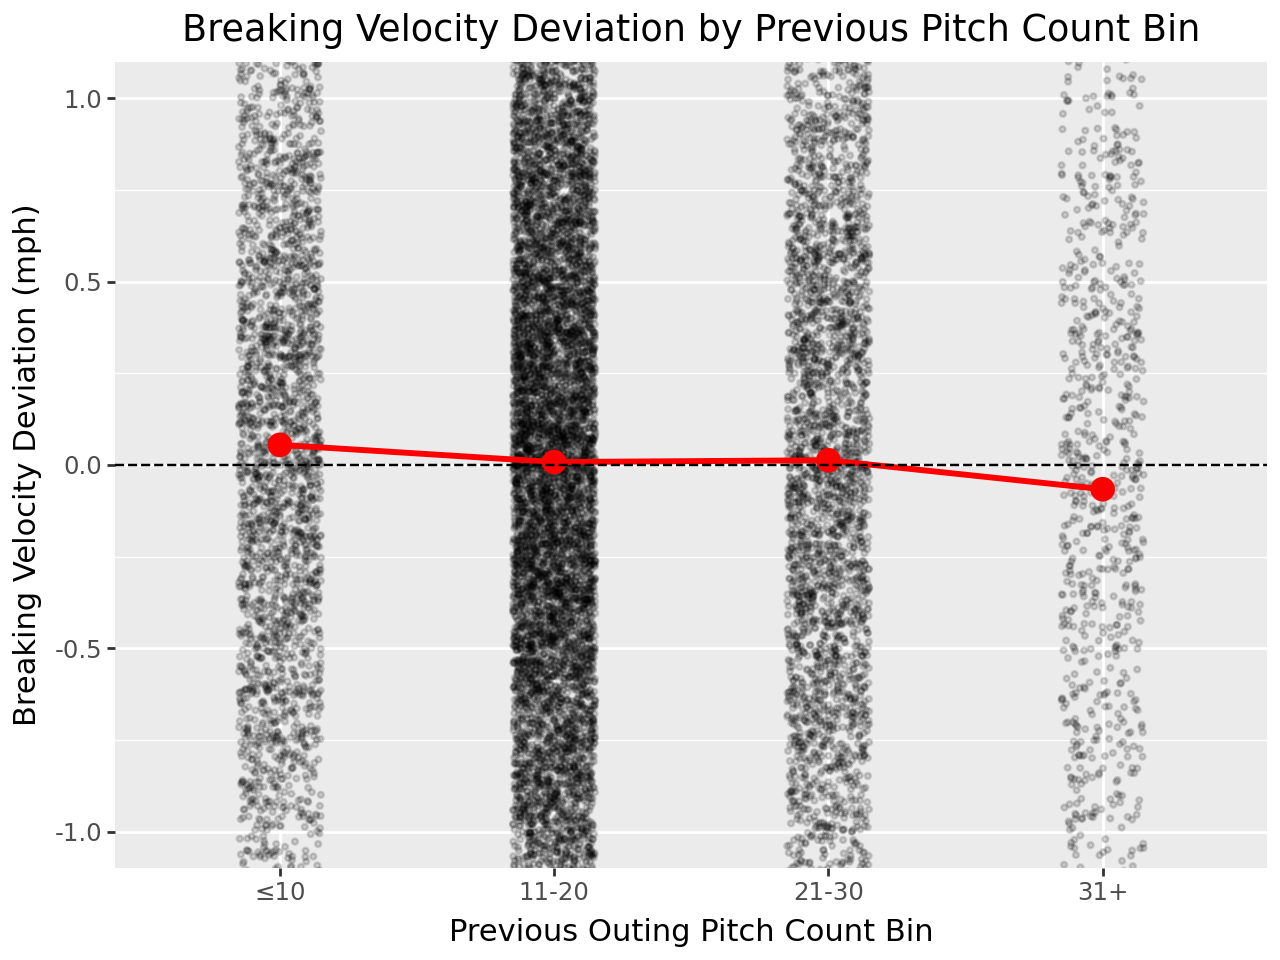

In [16]:
plot_df = (
    complete_outing_table_breaking
    .select(["prev_pitch_bin", "break_velo_deviation"])
    .drop_nulls(["prev_pitch_bin", "break_velo_deviation"])
    .to_pandas()
)

order = ["≤10", "11-20", "21-30", "31+"]
plot_df["prev_pitch_bin"] = pd.Categorical(
    plot_df["prev_pitch_bin"],
    categories=order,
    ordered=True
)

mean_df = (
    plot_df
    .groupby("prev_pitch_bin", as_index=False)
    .mean(numeric_only=True)
)

(
    ggplot(plot_df, aes(x="prev_pitch_bin", y="break_velo_deviation")) +
    geom_jitter(alpha=0.15, width=0.15, size=0.7) +
    geom_line(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="break_velo_deviation", group=1),
        color="red",
        size=1.2
    ) +
    geom_point(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="break_velo_deviation"),
        color="red",
        size=4
    ) +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-1, 1)) +
    labs(
        title="Breaking Velocity Deviation by Previous Pitch Count Bin",
        x="Previous Outing Pitch Count Bin",
        y="Breaking Velocity Deviation (mph)"
    )
)

## Offspeed

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 30267 rows containing missing values.


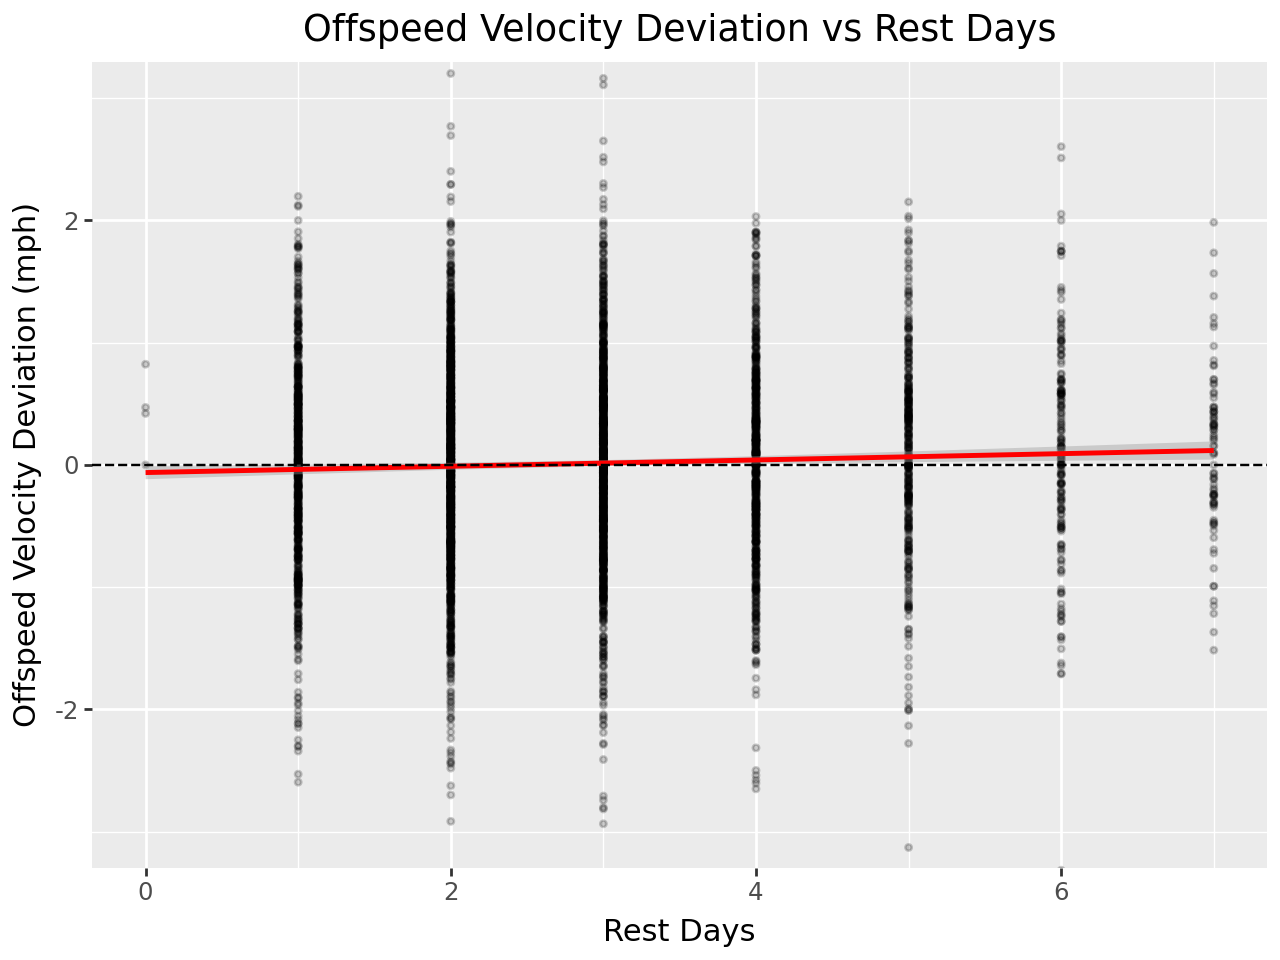

In [17]:
(
    ggplot(complete_outing_table_offspeed, aes(x="rest_days", y="off_velo_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-3, 3)) +
    labs(
        title="Offspeed Velocity Deviation vs Rest Days",
        x="Rest Days",
        y="Offspeed Velocity Deviation (mph)"
    )
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 30267 rows containing missing values.


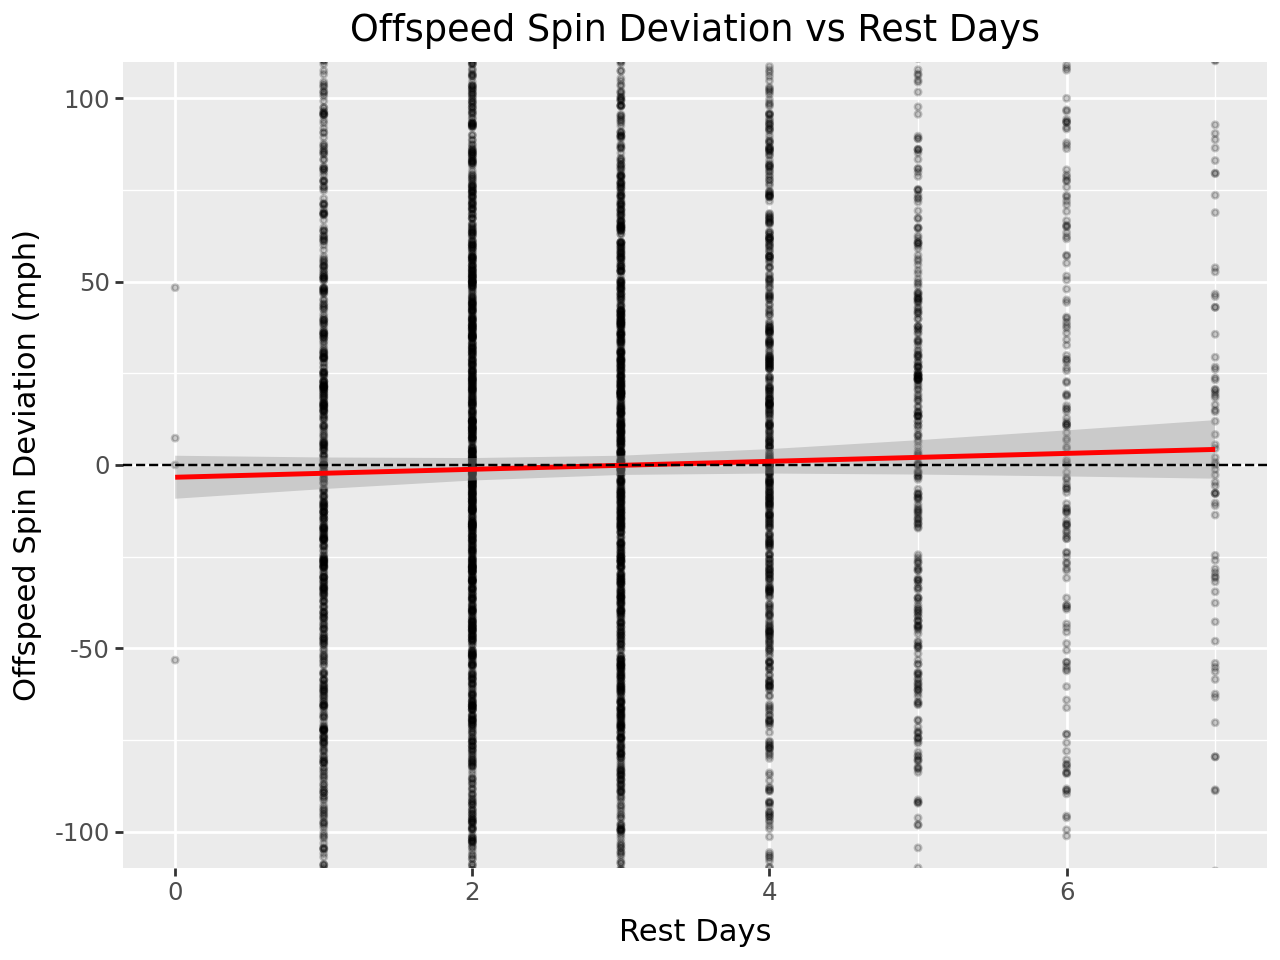

In [18]:
(
    ggplot(complete_outing_table_offspeed, aes(x="rest_days", y="off_spin_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-100, 100)) +
    labs(
        title="Offspeed Spin Deviation vs Rest Days",
        x="Rest Days",
        y="Offspeed Spin Deviation (mph)"
    )
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 30267 rows containing missing values.


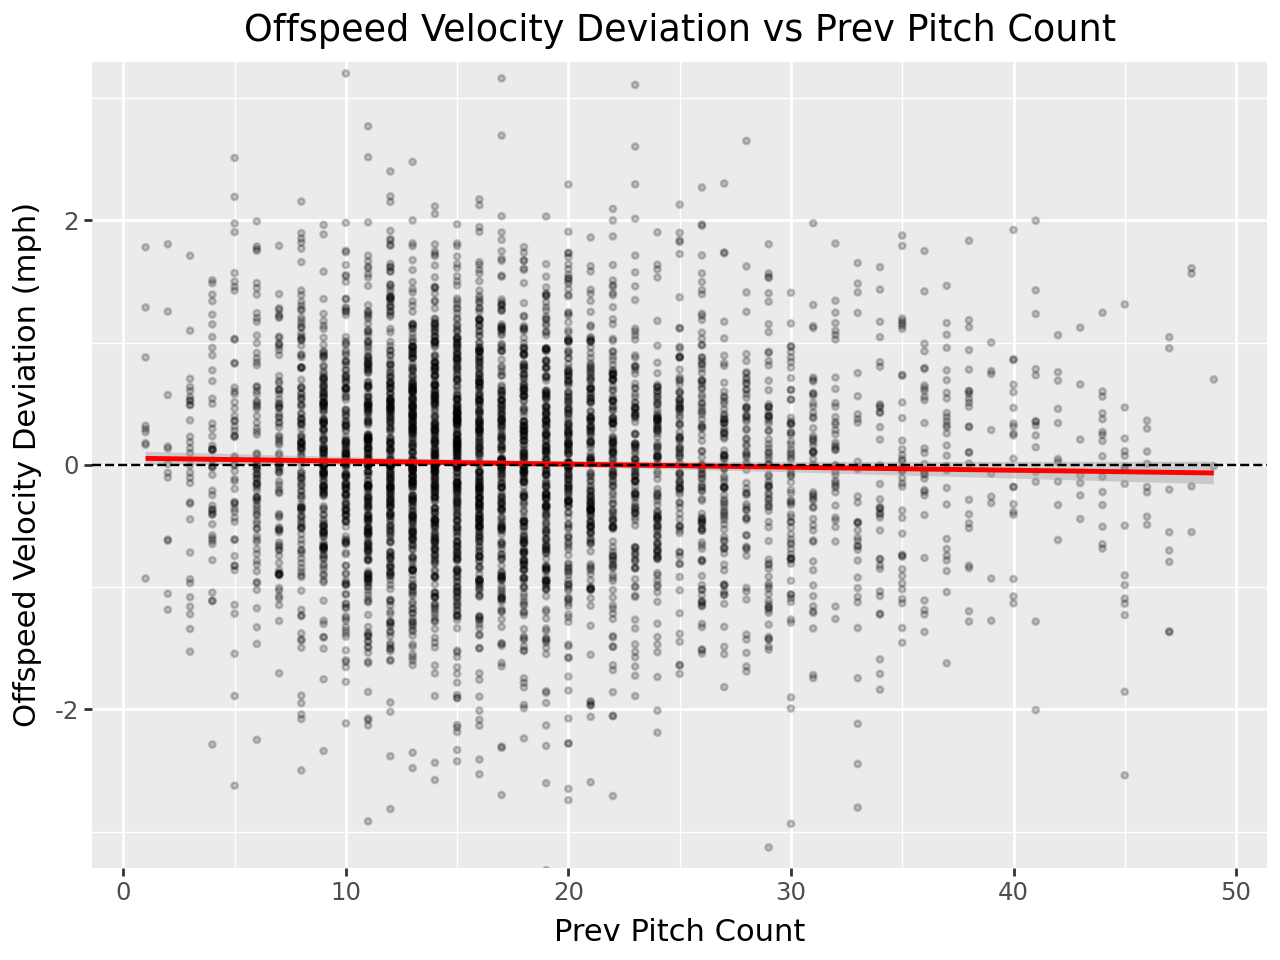

In [19]:
(
    ggplot(complete_outing_table_offspeed, aes(x="prev_pitch_count", y="off_velo_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-3, 3)) +
    labs(
        title="Offspeed Velocity Deviation vs Prev Pitch Count",
        x="Prev Pitch Count",
        y="Offspeed Velocity Deviation (mph)"
    )
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 30267 rows containing missing values.


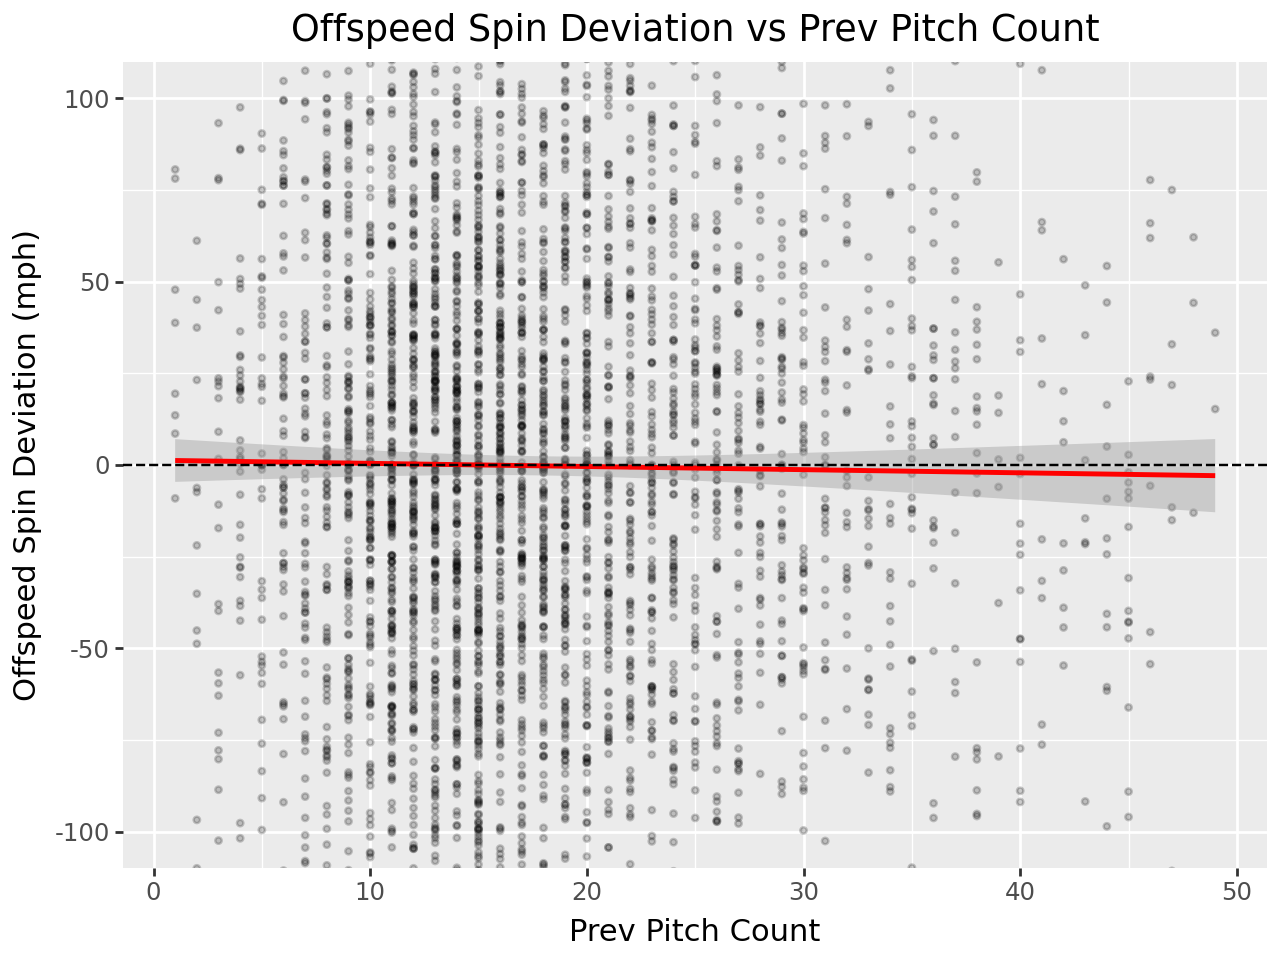

In [20]:
(
    ggplot(complete_outing_table_offspeed, aes(x="prev_pitch_count", y="off_spin_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-100, 100)) +
    labs(
        title="Offspeed Spin Deviation vs Prev Pitch Count",
        x="Prev Pitch Count",
        y="Offspeed Spin Deviation (mph)"
    )
)

prev pitch bin

C:\Users\kh6102sj\AppData\Local\Temp\ipykernel_7268\1583702042.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


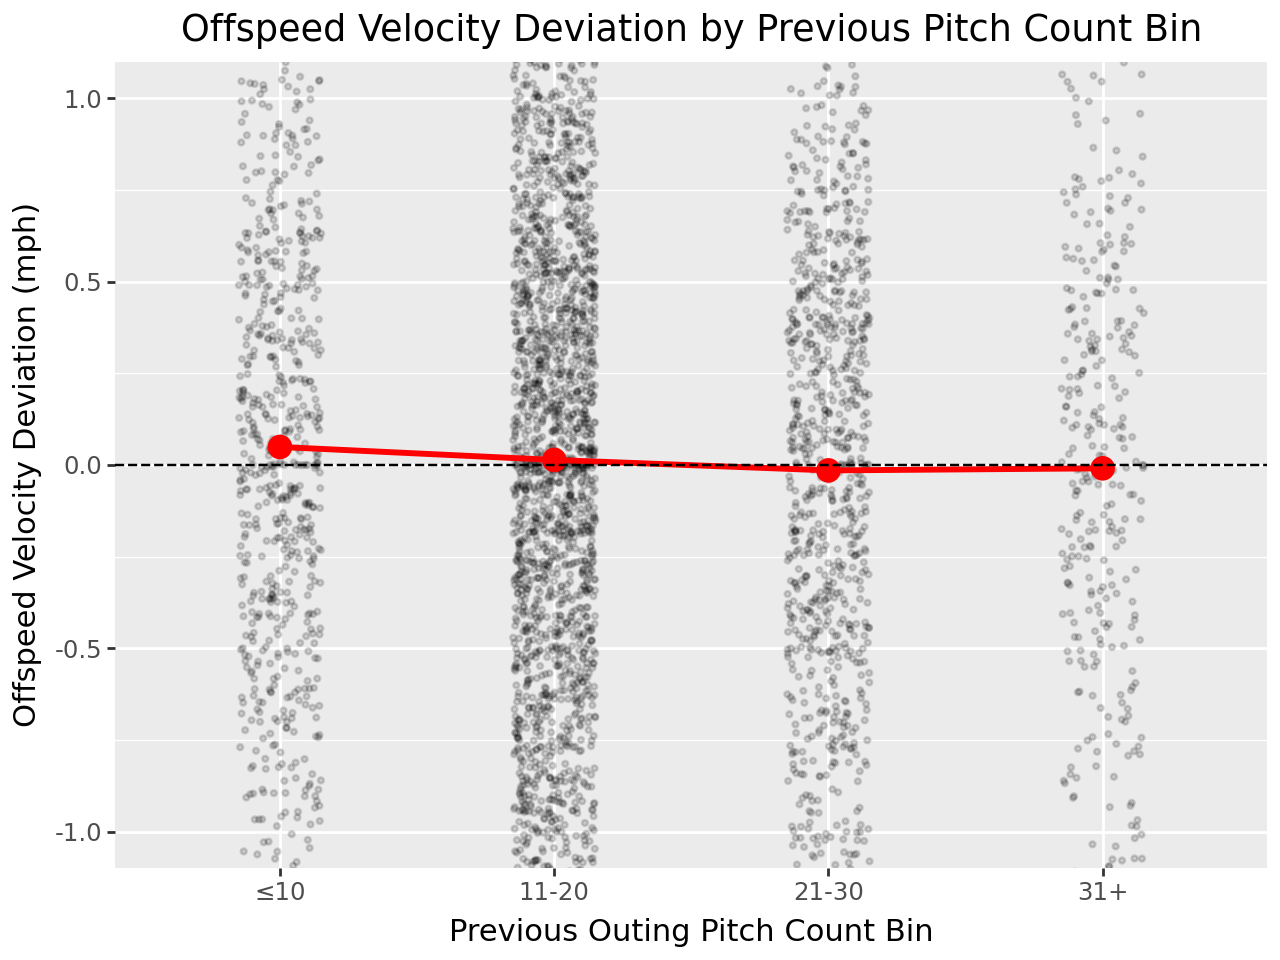

In [21]:
plot_df = (
    complete_outing_table_offspeed
    .select(["prev_pitch_bin", "off_velo_deviation"])
    .drop_nulls(["prev_pitch_bin", "off_velo_deviation"])
    .to_pandas()
)

order = ["≤10", "11-20", "21-30", "31+"]
plot_df["prev_pitch_bin"] = pd.Categorical(
    plot_df["prev_pitch_bin"],
    categories=order,
    ordered=True
)

mean_df = (
    plot_df
    .groupby("prev_pitch_bin", as_index=False)
    .mean(numeric_only=True)
)

(
    ggplot(plot_df, aes(x="prev_pitch_bin", y="off_velo_deviation")) +
    geom_jitter(alpha=0.15, width=0.15, size=0.7) +
    geom_line(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="off_velo_deviation", group=1),
        color="red",
        size=1.2
    ) +
    geom_point(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="off_velo_deviation"),
        color="red",
        size=4
    ) +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-1, 1)) +
    labs(
        title="Offspeed Velocity Deviation by Previous Pitch Count Bin",
        x="Previous Outing Pitch Count Bin",
        y="Offspeed Velocity Deviation (mph)"
    )
)

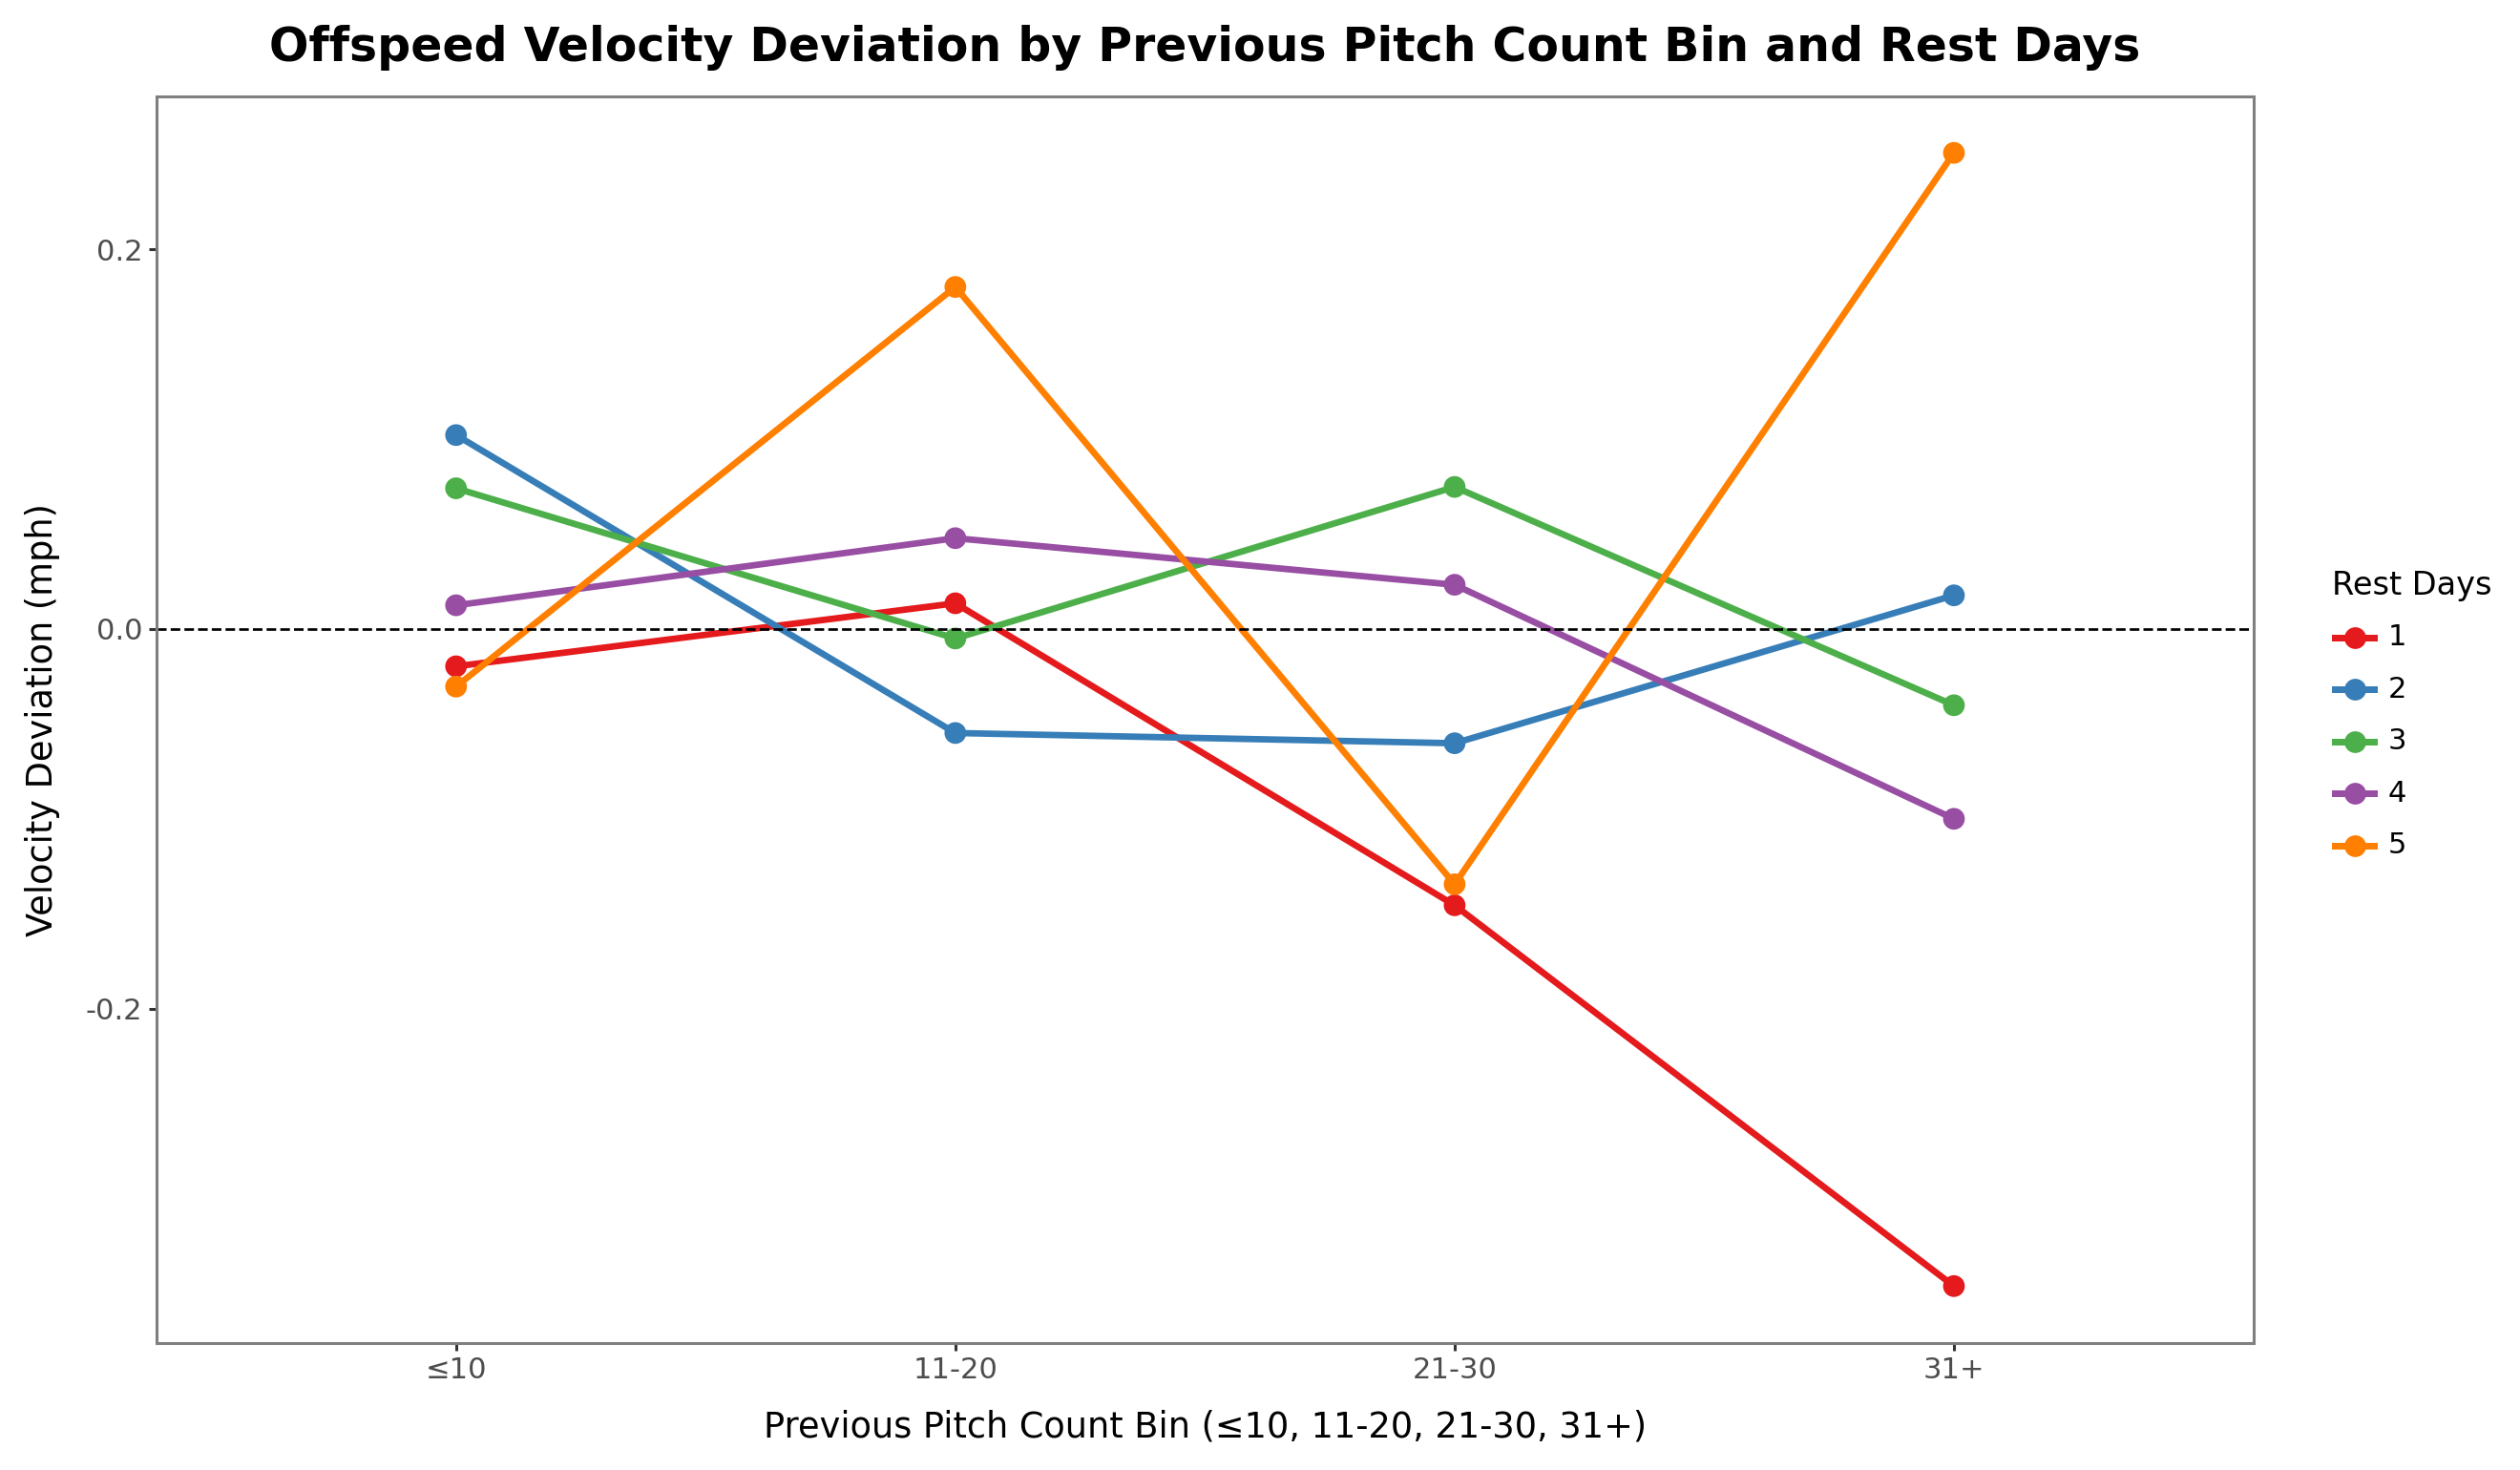

In [50]:
# Offspeed velocity: previous pitch-count bin x rest-day groups (1-5)
off_velo_plot = (
    complete_outing_table_offspeed
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "off_velo_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "off_velo_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("off_velo_deviation").alias("avg_velo_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
off_velo_plot["prev_pitch_bin"] = pd.Categorical(
    off_velo_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
off_velo_plot = off_velo_plot.sort_values(["rest_days", "prev_pitch_bin"])

(
    ggplot(
        off_velo_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_velo_deviation",
            group="factor(rest_days)",
            color="factor(rest_days)",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_brewer(type="qual", palette="Set1")
    + labs(
        title="Offspeed Velocity Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Velocity Deviation (mph)",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

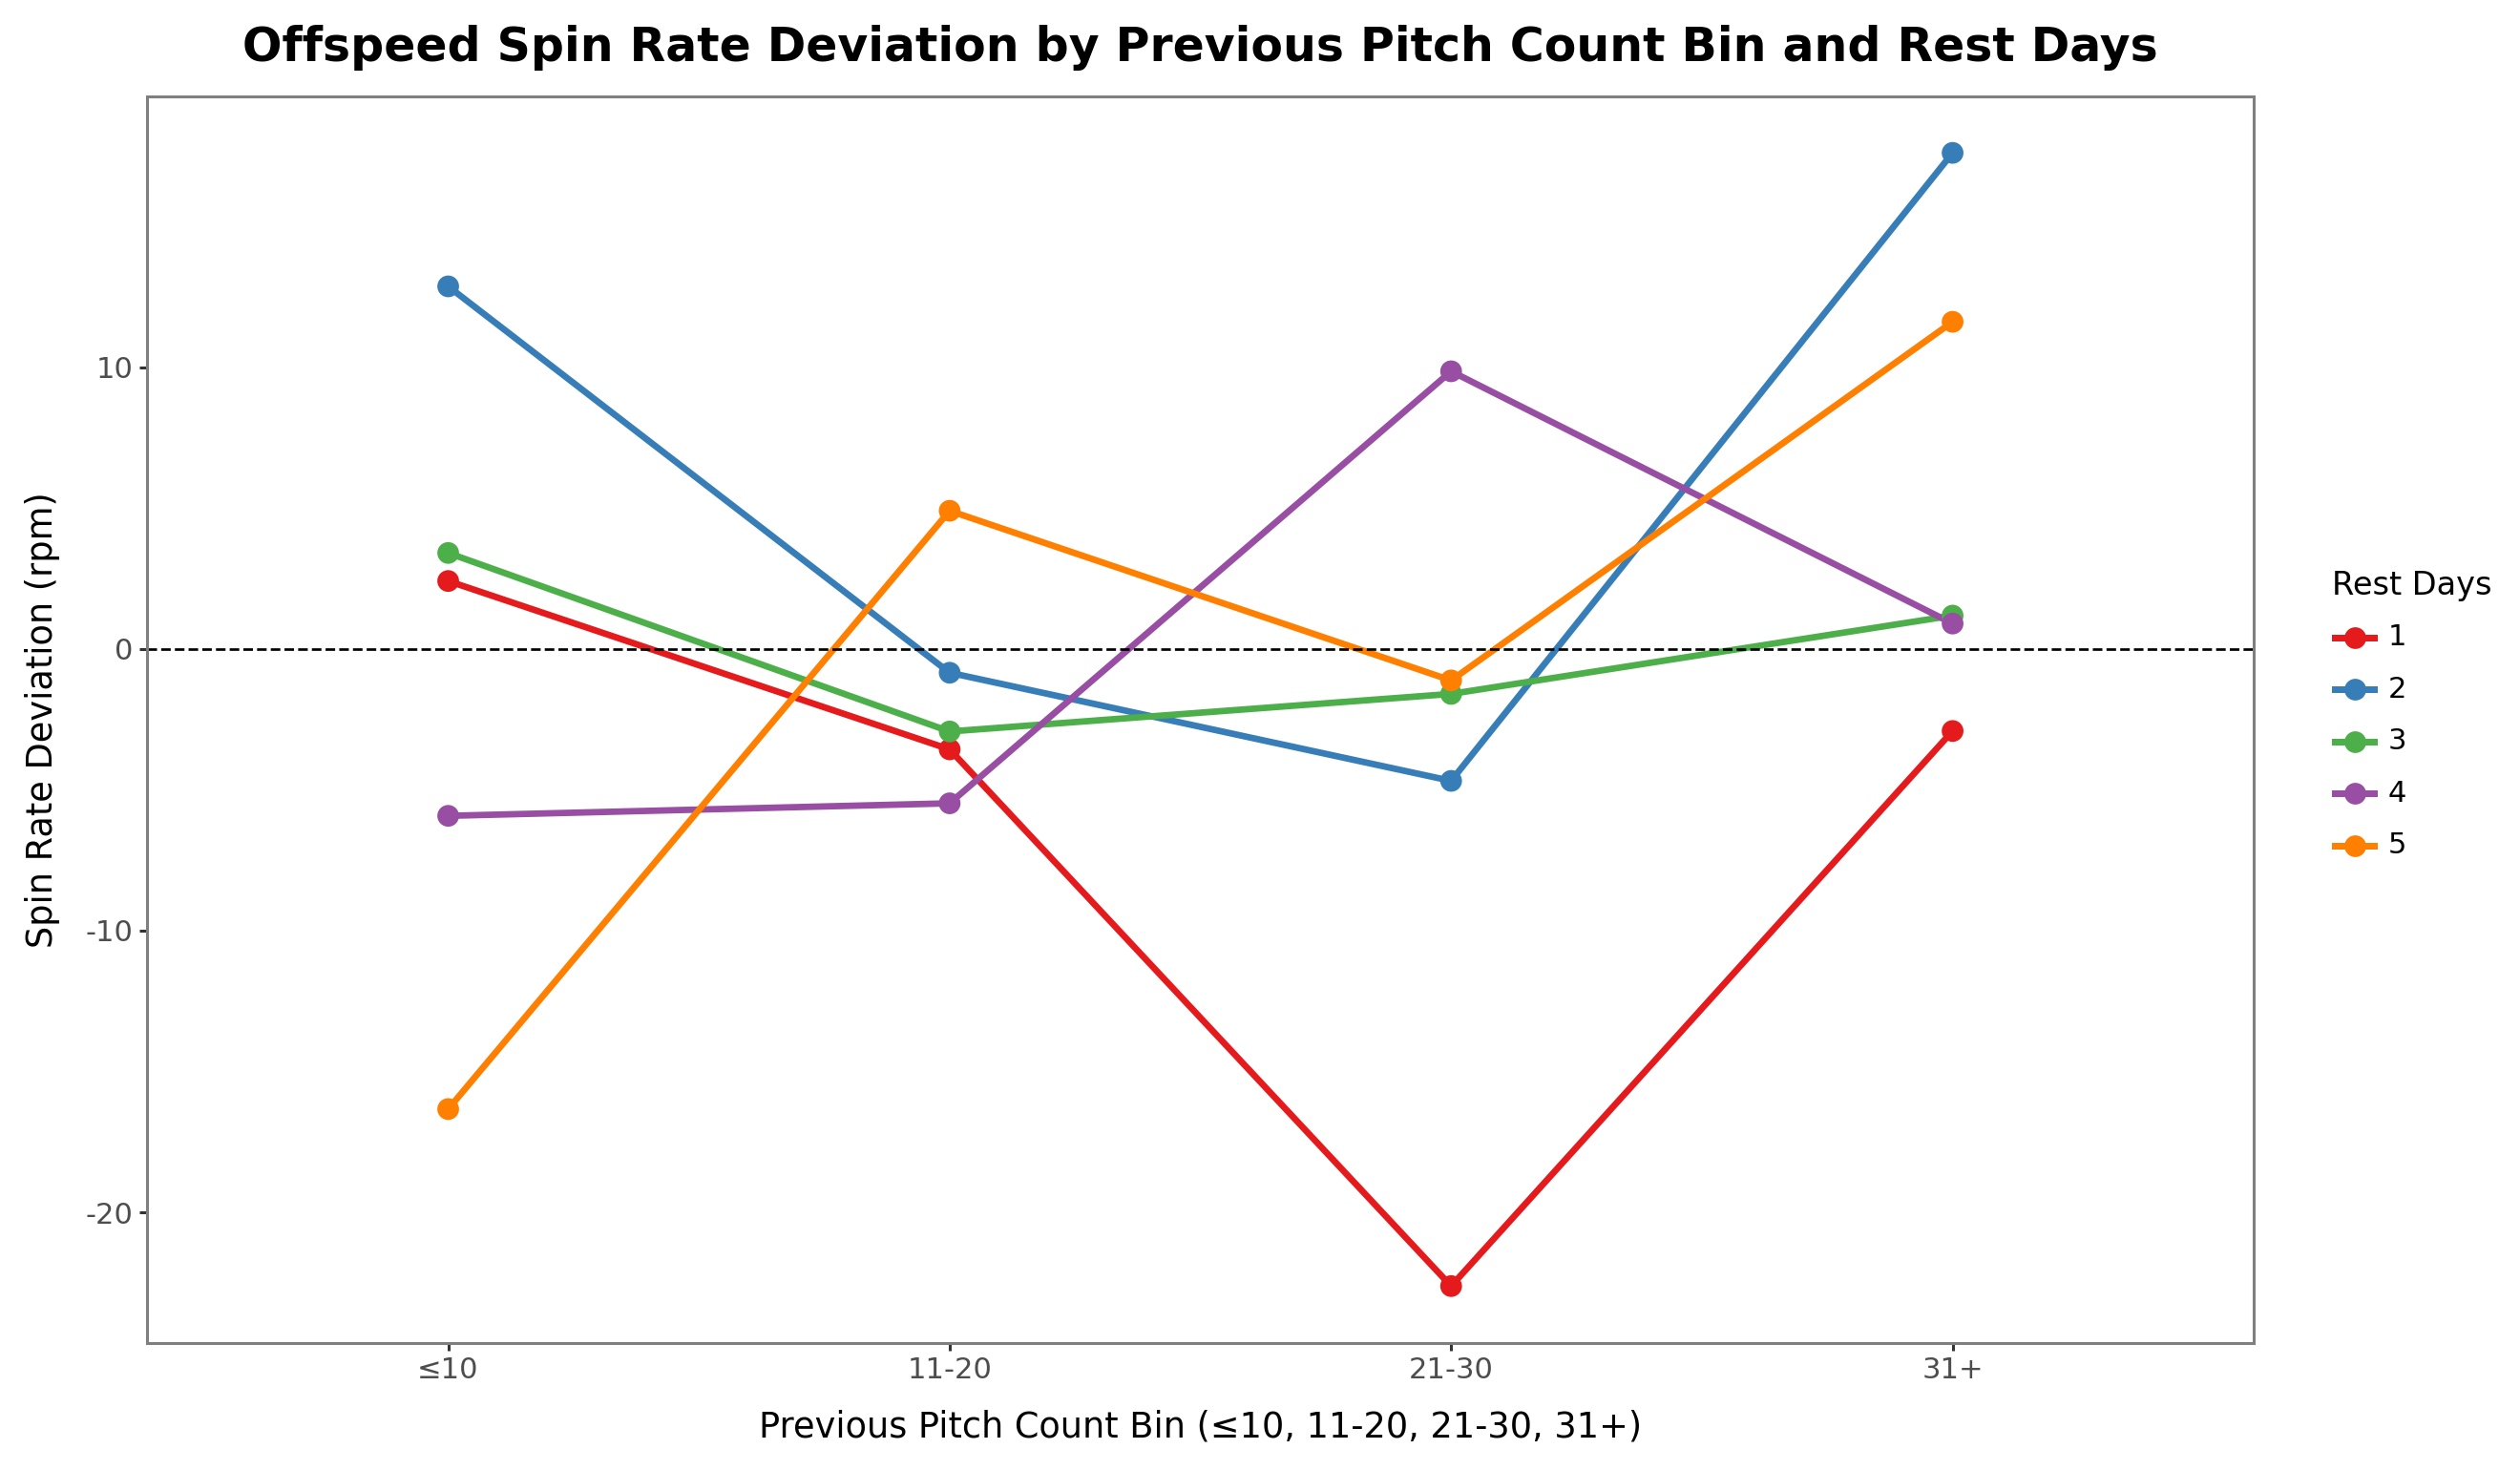

In [51]:
# Offspeed spin rate: previous pitch-count bin x rest-day groups (1-5)
off_spin_plot = (
    complete_outing_table_offspeed
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "off_spin_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "off_spin_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("off_spin_deviation").alias("avg_spin_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
off_spin_plot["prev_pitch_bin"] = pd.Categorical(
    off_spin_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
off_spin_plot = off_spin_plot.sort_values(["rest_days", "prev_pitch_bin"])

(
    ggplot(
        off_spin_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_spin_deviation",
            group="factor(rest_days)",
            color="factor(rest_days)",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_brewer(type="qual", palette="Set1")
    + labs(
        title="Offspeed Spin Rate Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Spin Rate Deviation (rpm)",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

In [37]:
# Movement deviation source table (horizontal + vertical)
movement_table = complete_outing_table.select([
    "rest_days",
    "prev_pitch_bin",
    "h_movement_deviation",
    "v_movement_deviation",
])

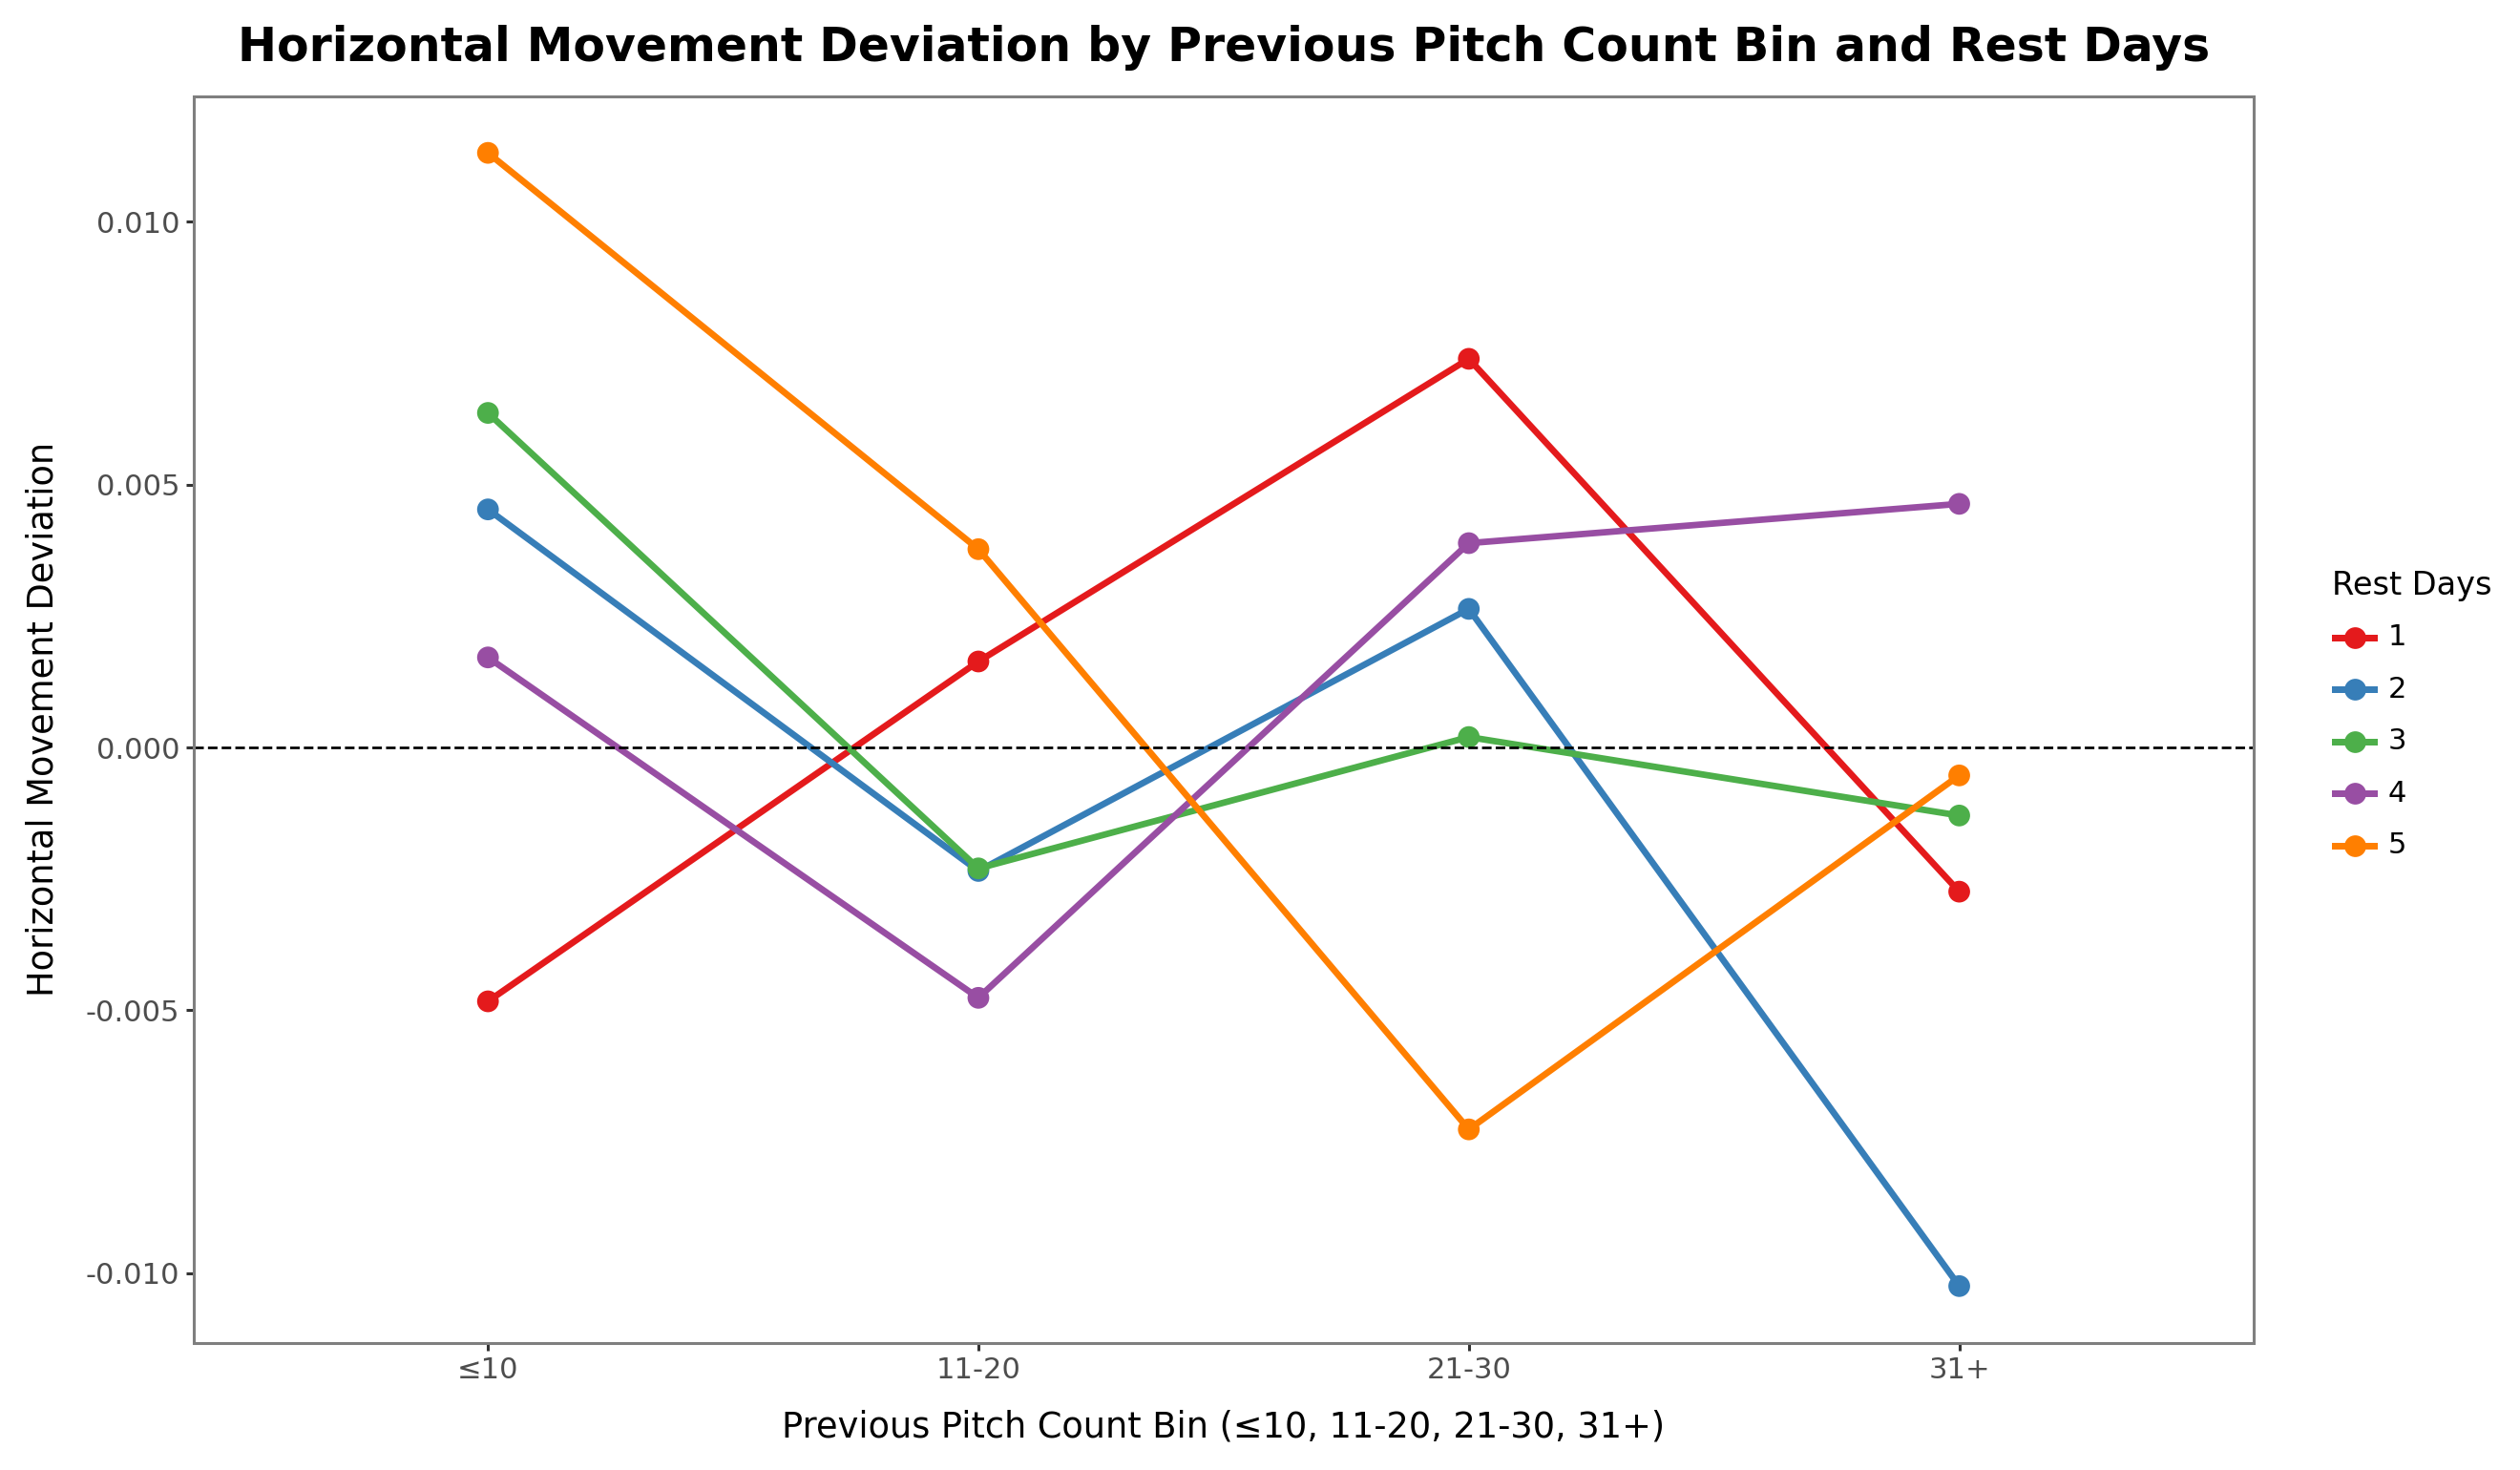

In [52]:
# Horizontal movement: previous pitch-count bin x rest-day groups (1-5)
off_hmov_plot = (
    movement_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "h_movement_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "h_movement_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("h_movement_deviation").alias("avg_hmov_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
off_hmov_plot["prev_pitch_bin"] = pd.Categorical(
    off_hmov_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
off_hmov_plot = off_hmov_plot.sort_values(["rest_days", "prev_pitch_bin"])

(
    ggplot(
        off_hmov_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_hmov_deviation",
            group="factor(rest_days)",
            color="factor(rest_days)",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_brewer(type="qual", palette="Set1")
    + labs(
        title="Horizontal Movement Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Horizontal Movement Deviation",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

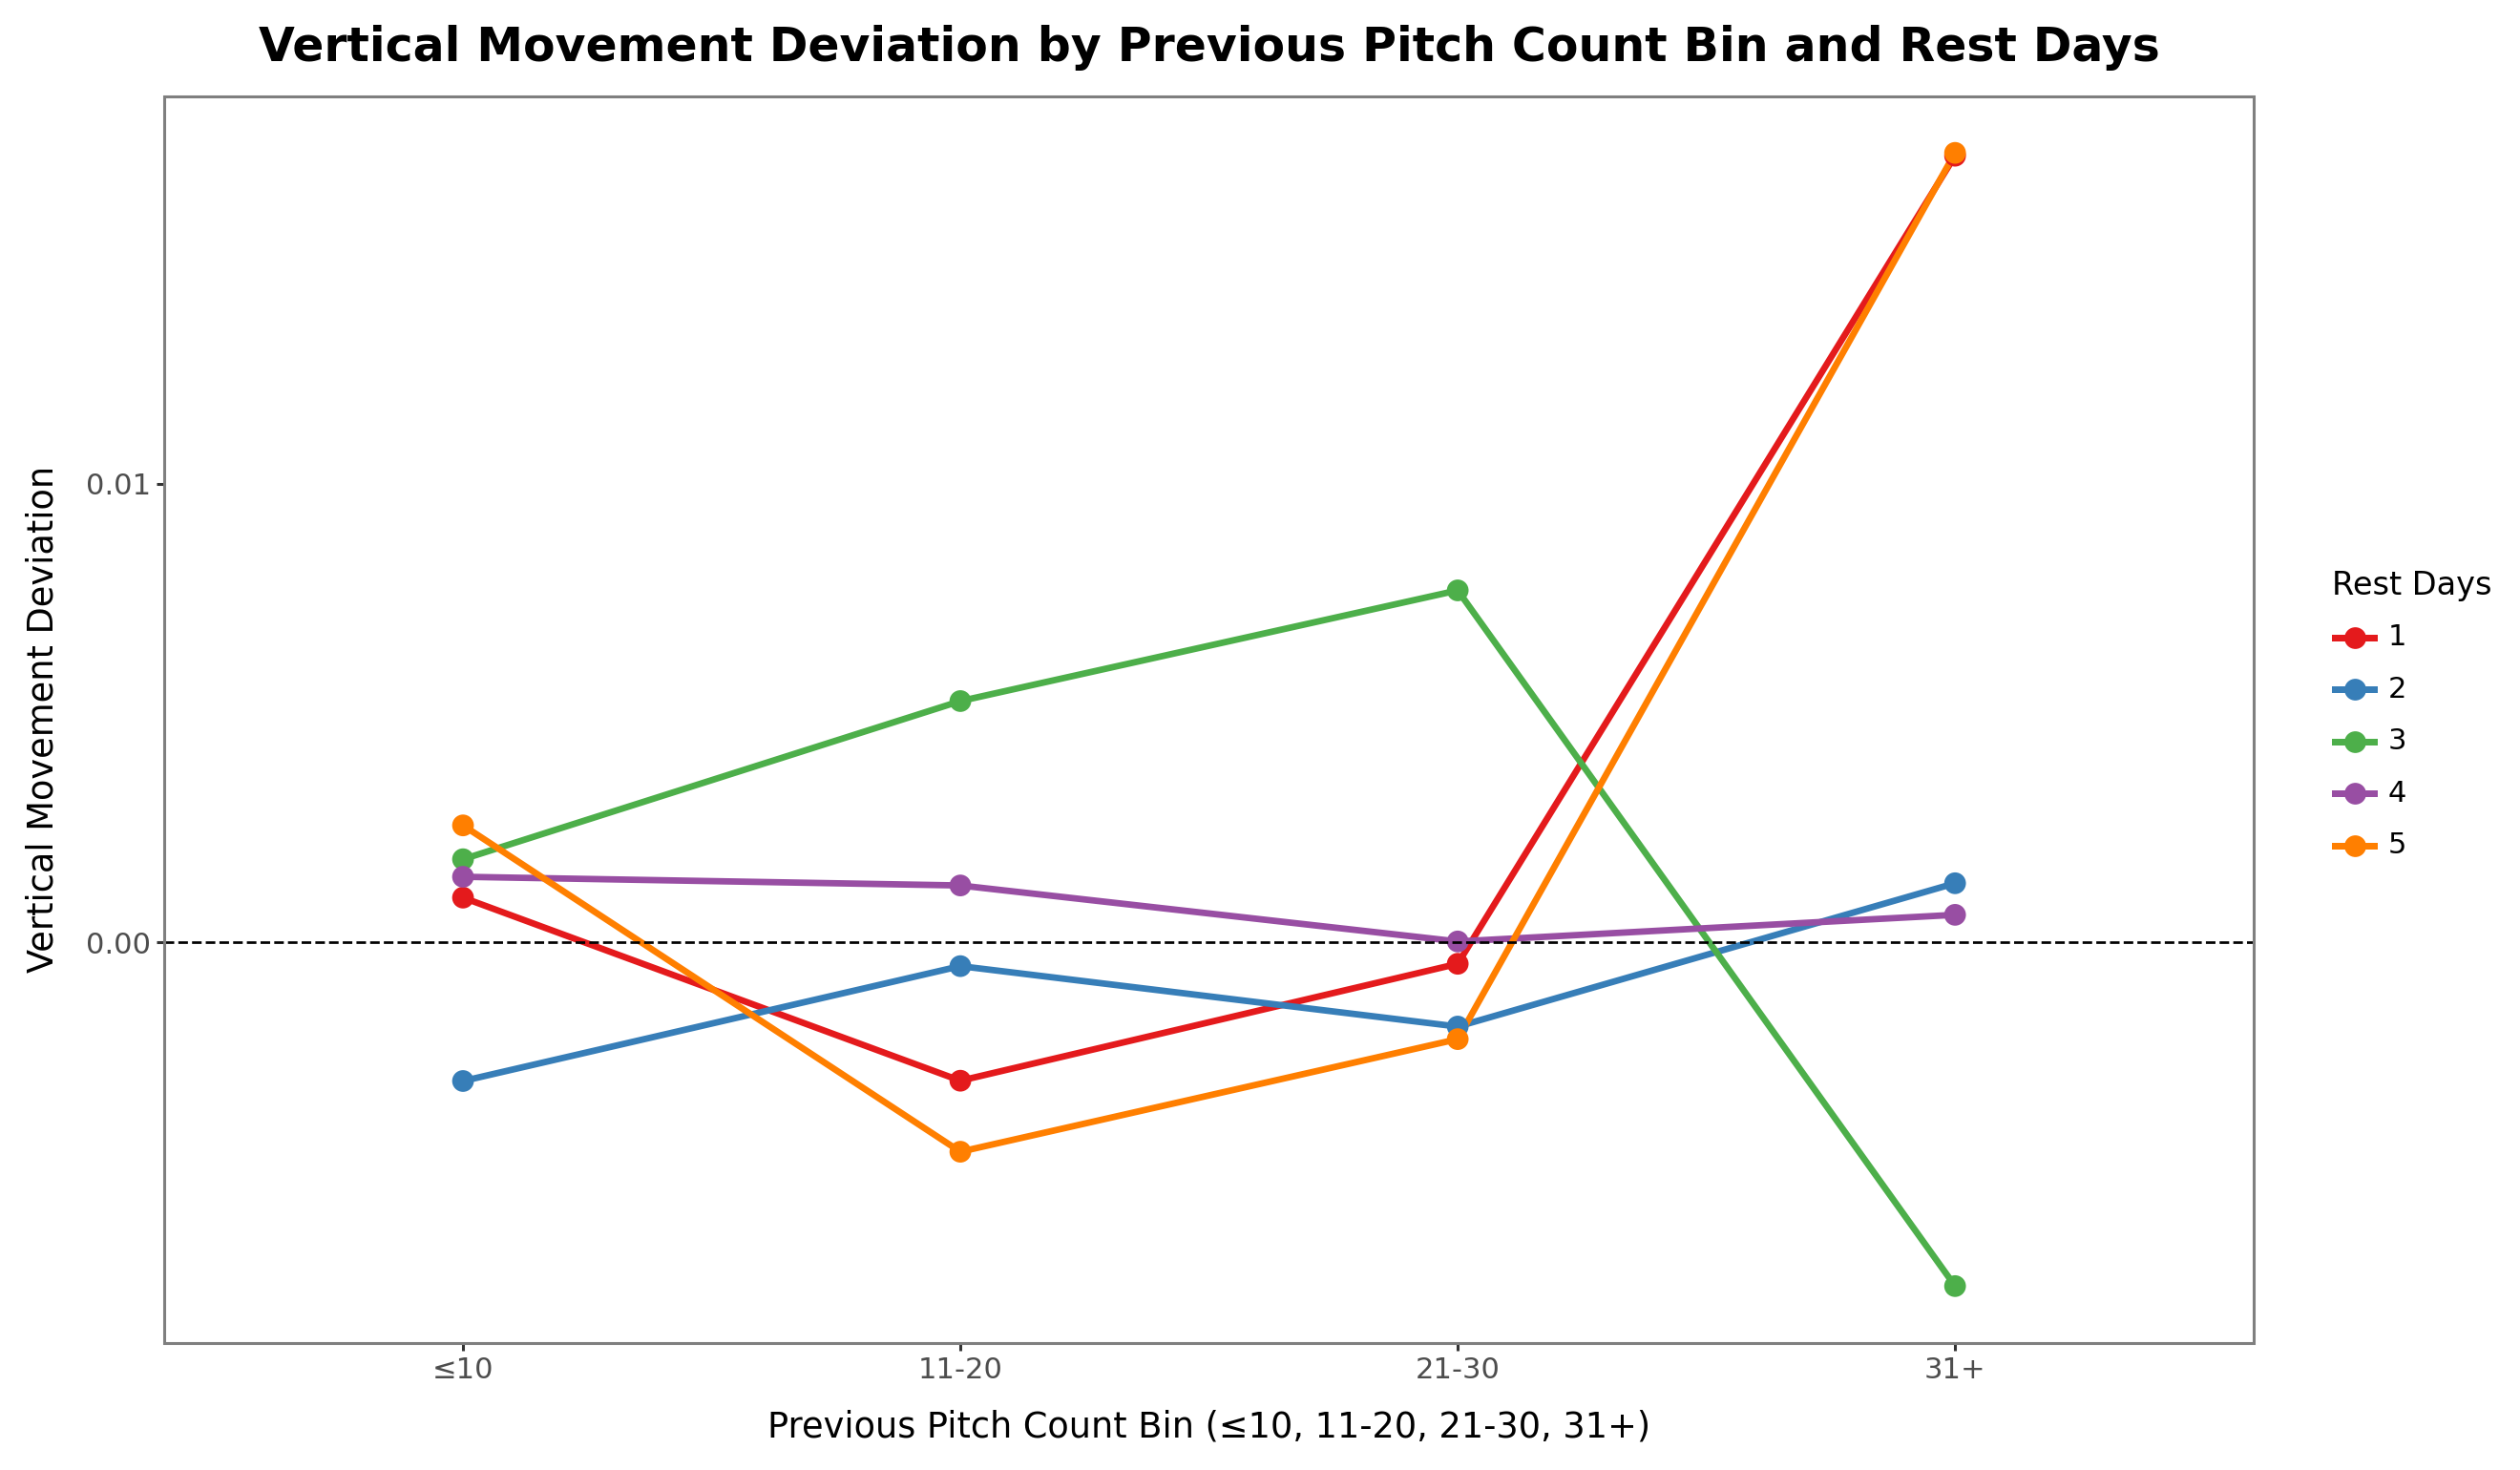

In [53]:
# Vertical movement: previous pitch-count bin x rest-day groups (1-5)
off_vmov_plot = (
    movement_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "v_movement_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "v_movement_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("v_movement_deviation").alias("avg_vmov_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
off_vmov_plot["prev_pitch_bin"] = pd.Categorical(
    off_vmov_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
off_vmov_plot = off_vmov_plot.sort_values(["rest_days", "prev_pitch_bin"])

(
    ggplot(
        off_vmov_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_vmov_deviation",
            group="factor(rest_days)",
            color="factor(rest_days)",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_brewer(type="qual", palette="Set1")
    + labs(
        title="Vertical Movement Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Vertical Movement Deviation",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

models 

# Specifically Sliders

In [42]:
(slider_metrics := (
    relievers
    .filter(pl.col("pitch_type_abbr") == "SL")
    .drop_nulls(["velocity", "spin_rate", "pitcher_id", "game_id", "year"])
    .group_by(["pitcher_id", "game_id", "year"])
    .agg([
        pl.mean("velocity").alias("mean_slider_velo"),
        pl.mean("spin_rate").alias("mean_slider_spin"),
        pl.len().alias("slider_pitch_count"),
    ])
    .filter(pl.col("slider_pitch_count") >= min_family_pitches)
    .with_columns([
        pl.col("mean_slider_velo").mean().over(["pitcher_id", "year"]).alias("season_avg_slider_velo"),
        pl.col("mean_slider_spin").mean().over(["pitcher_id", "year"]).alias("season_avg_slider_spin"),
    ])
    .with_columns([
        (pl.col("mean_slider_velo") - pl.col("season_avg_slider_velo")).alias("slider_velo_deviation"),
        (pl.col("mean_slider_spin") - pl.col("season_avg_slider_spin")).alias("slider_spin_deviation"),
    ])
)).head(5)

pitcher_id,game_id,year,mean_slider_velo,mean_slider_spin,slider_pitch_count,season_avg_slider_velo,season_avg_slider_spin,slider_velo_deviation,slider_spin_deviation
i64,i64,i32,f64,f64,u32,f64,f64,f64,f64
666808,746969,2024,88.4875,2402.5,8,88.797549,2485.369992,-0.310049,-82.869992
676714,661927,2022,82.4,2467.5,8,82.801494,2366.644808,-0.401494,100.855192
621383,662757,2022,87.191667,2317.416667,12,86.758077,2325.756797,0.43359,-8.34013
650895,634522,2021,88.185714,2268.428571,7,87.304308,2270.550258,0.881406,-2.121686
503449,663331,2022,85.32,2217.0,5,83.530593,2253.390138,1.789407,-36.390138


In [43]:
(slider_outing_table := (
    complete_outing_table
    .select(["pitcher_id", "game_id", "rest_days", "prev_pitch_count", "prev_pitch_bin"])
    .join(
        slider_metrics.select([
            "pitcher_id", "game_id",
            "season_avg_slider_velo",
            "season_avg_slider_spin",
            "slider_pitch_count",
            "slider_velo_deviation",
            "slider_spin_deviation"
        ]),
        on=["pitcher_id", "game_id"],
        how="inner"   # use "left" if you want to keep outings without enough sliders
    )
)).head(3)

pitcher_id,game_id,rest_days,prev_pitch_count,prev_pitch_bin,season_avg_slider_velo,season_avg_slider_spin,slider_pitch_count,slider_velo_deviation,slider_spin_deviation
i64,i64,i64,u32,str,f64,f64,u32,f64,f64
445276,634531,2,19,"""11-20""",81.754417,2419.669167,5,1.585583,265.730833
445276,634363,2,23,"""21-30""",81.754417,2419.669167,5,-0.874417,-77.269167
445276,633471,1,11,"""11-20""",81.754417,2419.669167,5,2.605583,118.530833


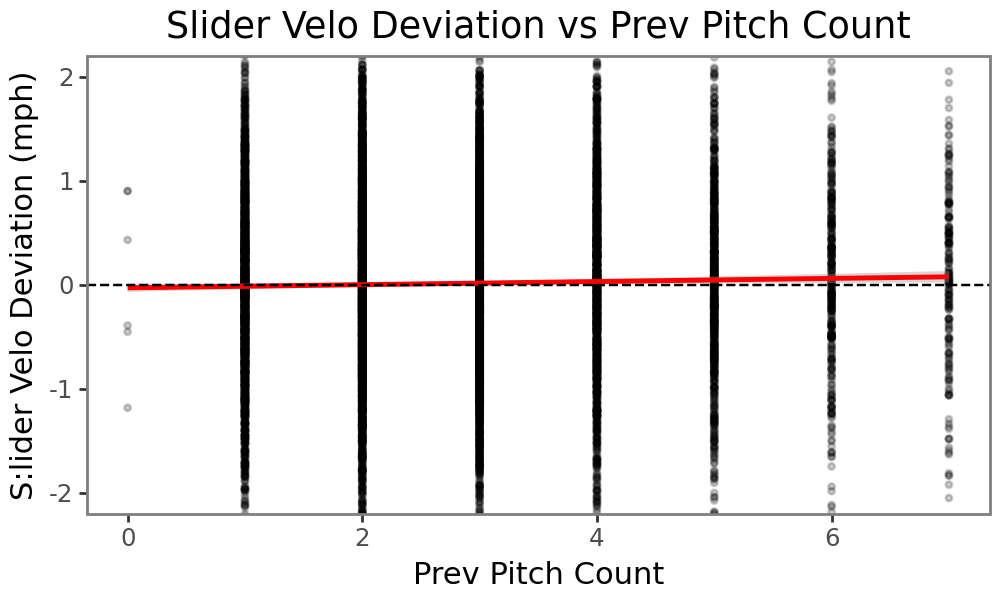

In [59]:
(
    ggplot(slider_outing_table, aes(x="rest_days", y="slider_velo_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-2, 2)) +
    labs(
        title="Slider Velo Deviation vs Prev Pitch Count",
        x="Prev Pitch Count",
        y="S:lider Velo Deviation (mph)"
    ) +
    theme_bw() +
    theme(
        figure_size=(5, 3),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white", color="white"),
        plot_background=element_rect(fill="white", color="white")
    )
)

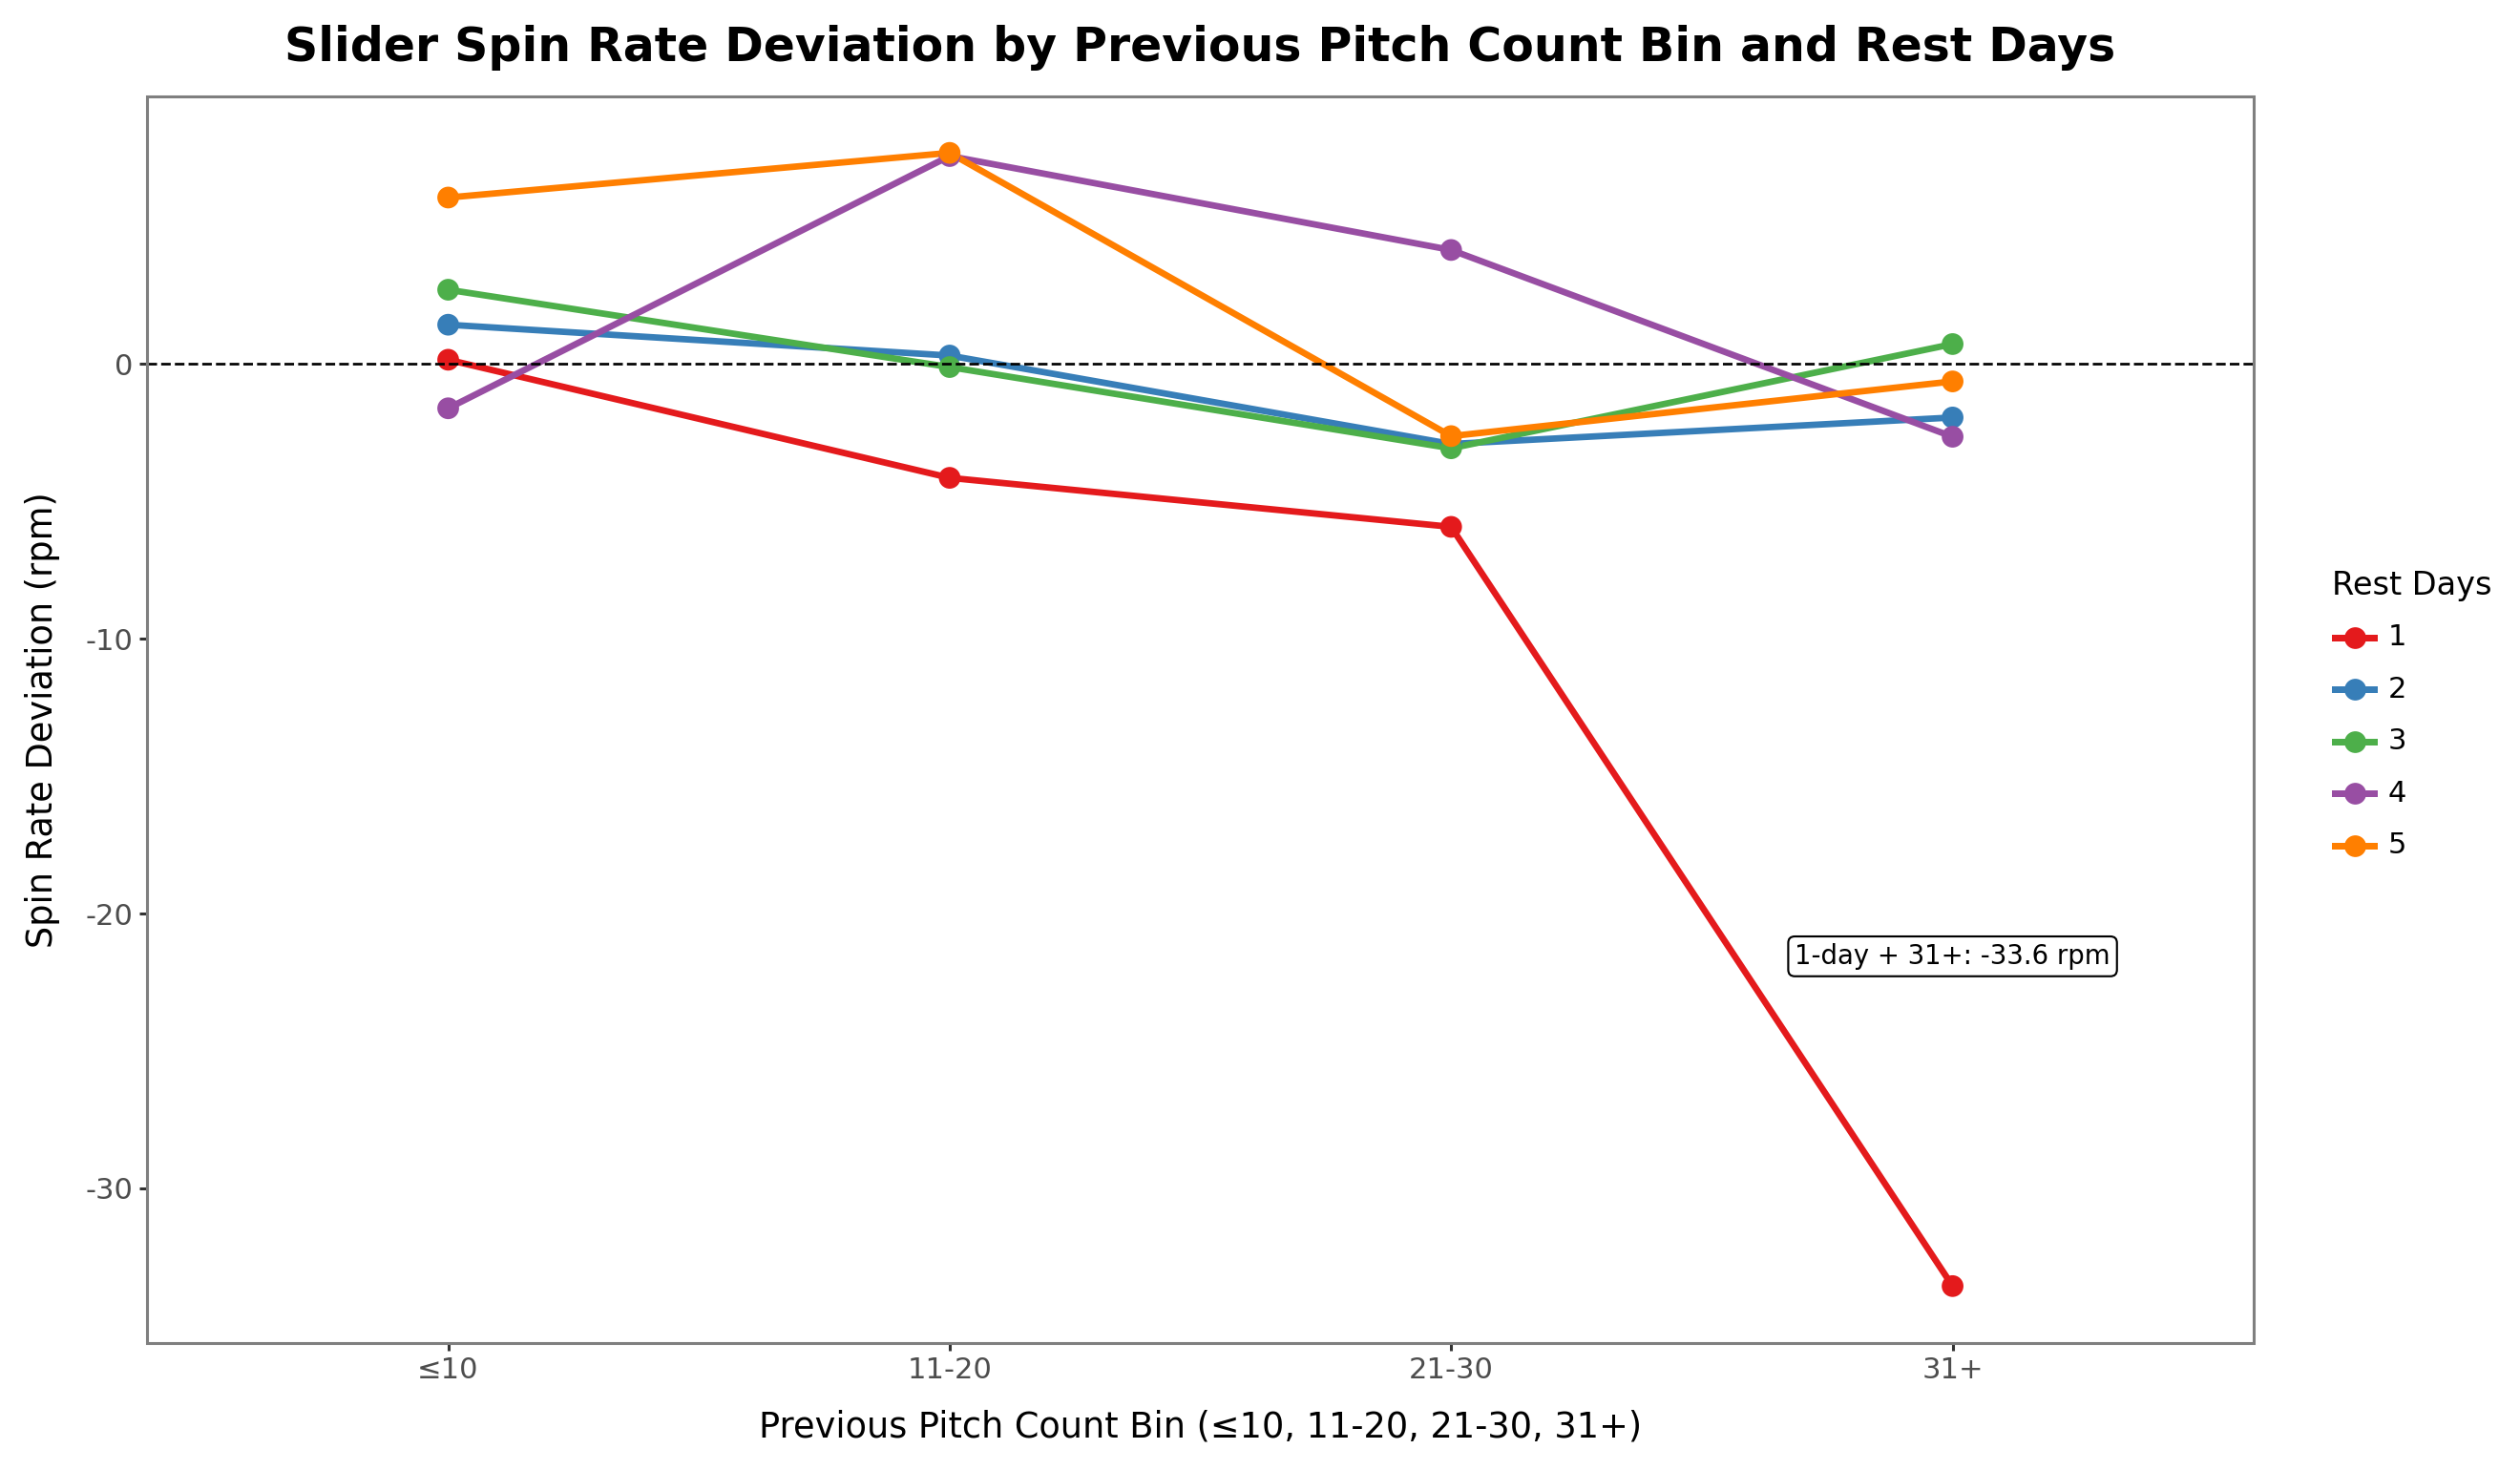

In [60]:
summary_plot_data = (
    slider_outing_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "slider_spin_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "slider_spin_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("slider_spin_deviation").alias("avg_spin_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
summary_plot_data["prev_pitch_bin"] = pd.Categorical(
    summary_plot_data["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
summary_plot_data = summary_plot_data.sort_values(["rest_days", "prev_pitch_bin"]).reset_index(drop=True)

ann_df = summary_plot_data[
    (summary_plot_data["rest_days"] == 1)
    & (summary_plot_data["prev_pitch_bin"] == "31+")
] .copy()

if not ann_df.empty:
    ann_df["label"] = ann_df["avg_spin_deviation"].map(
        lambda x: f"1-day + 31+: {x:.1f} rpm"
    )
else:
    ann_df = pd.DataFrame(
        columns=["rest_days", "prev_pitch_bin", "avg_spin_deviation", "label"]
    )

(
    ggplot(
        summary_plot_data,
        aes(
            x="prev_pitch_bin",
            y="avg_spin_deviation",
            group="factor(rest_days)",
            color="factor(rest_days)",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_brewer(type="qual", palette="Set1")
    + geom_label(
        data=ann_df,
        mapping=aes(x="prev_pitch_bin", y="avg_spin_deviation", label="label"),
        fill="white",
        color="black",
        size=9,
        nudge_y=12,
        show_legend=False,
    )
    + labs(
        title="Slider Spin Rate Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Spin Rate Deviation (rpm)",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white", color="white"),
        plot_background=element_rect(fill="white", color="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

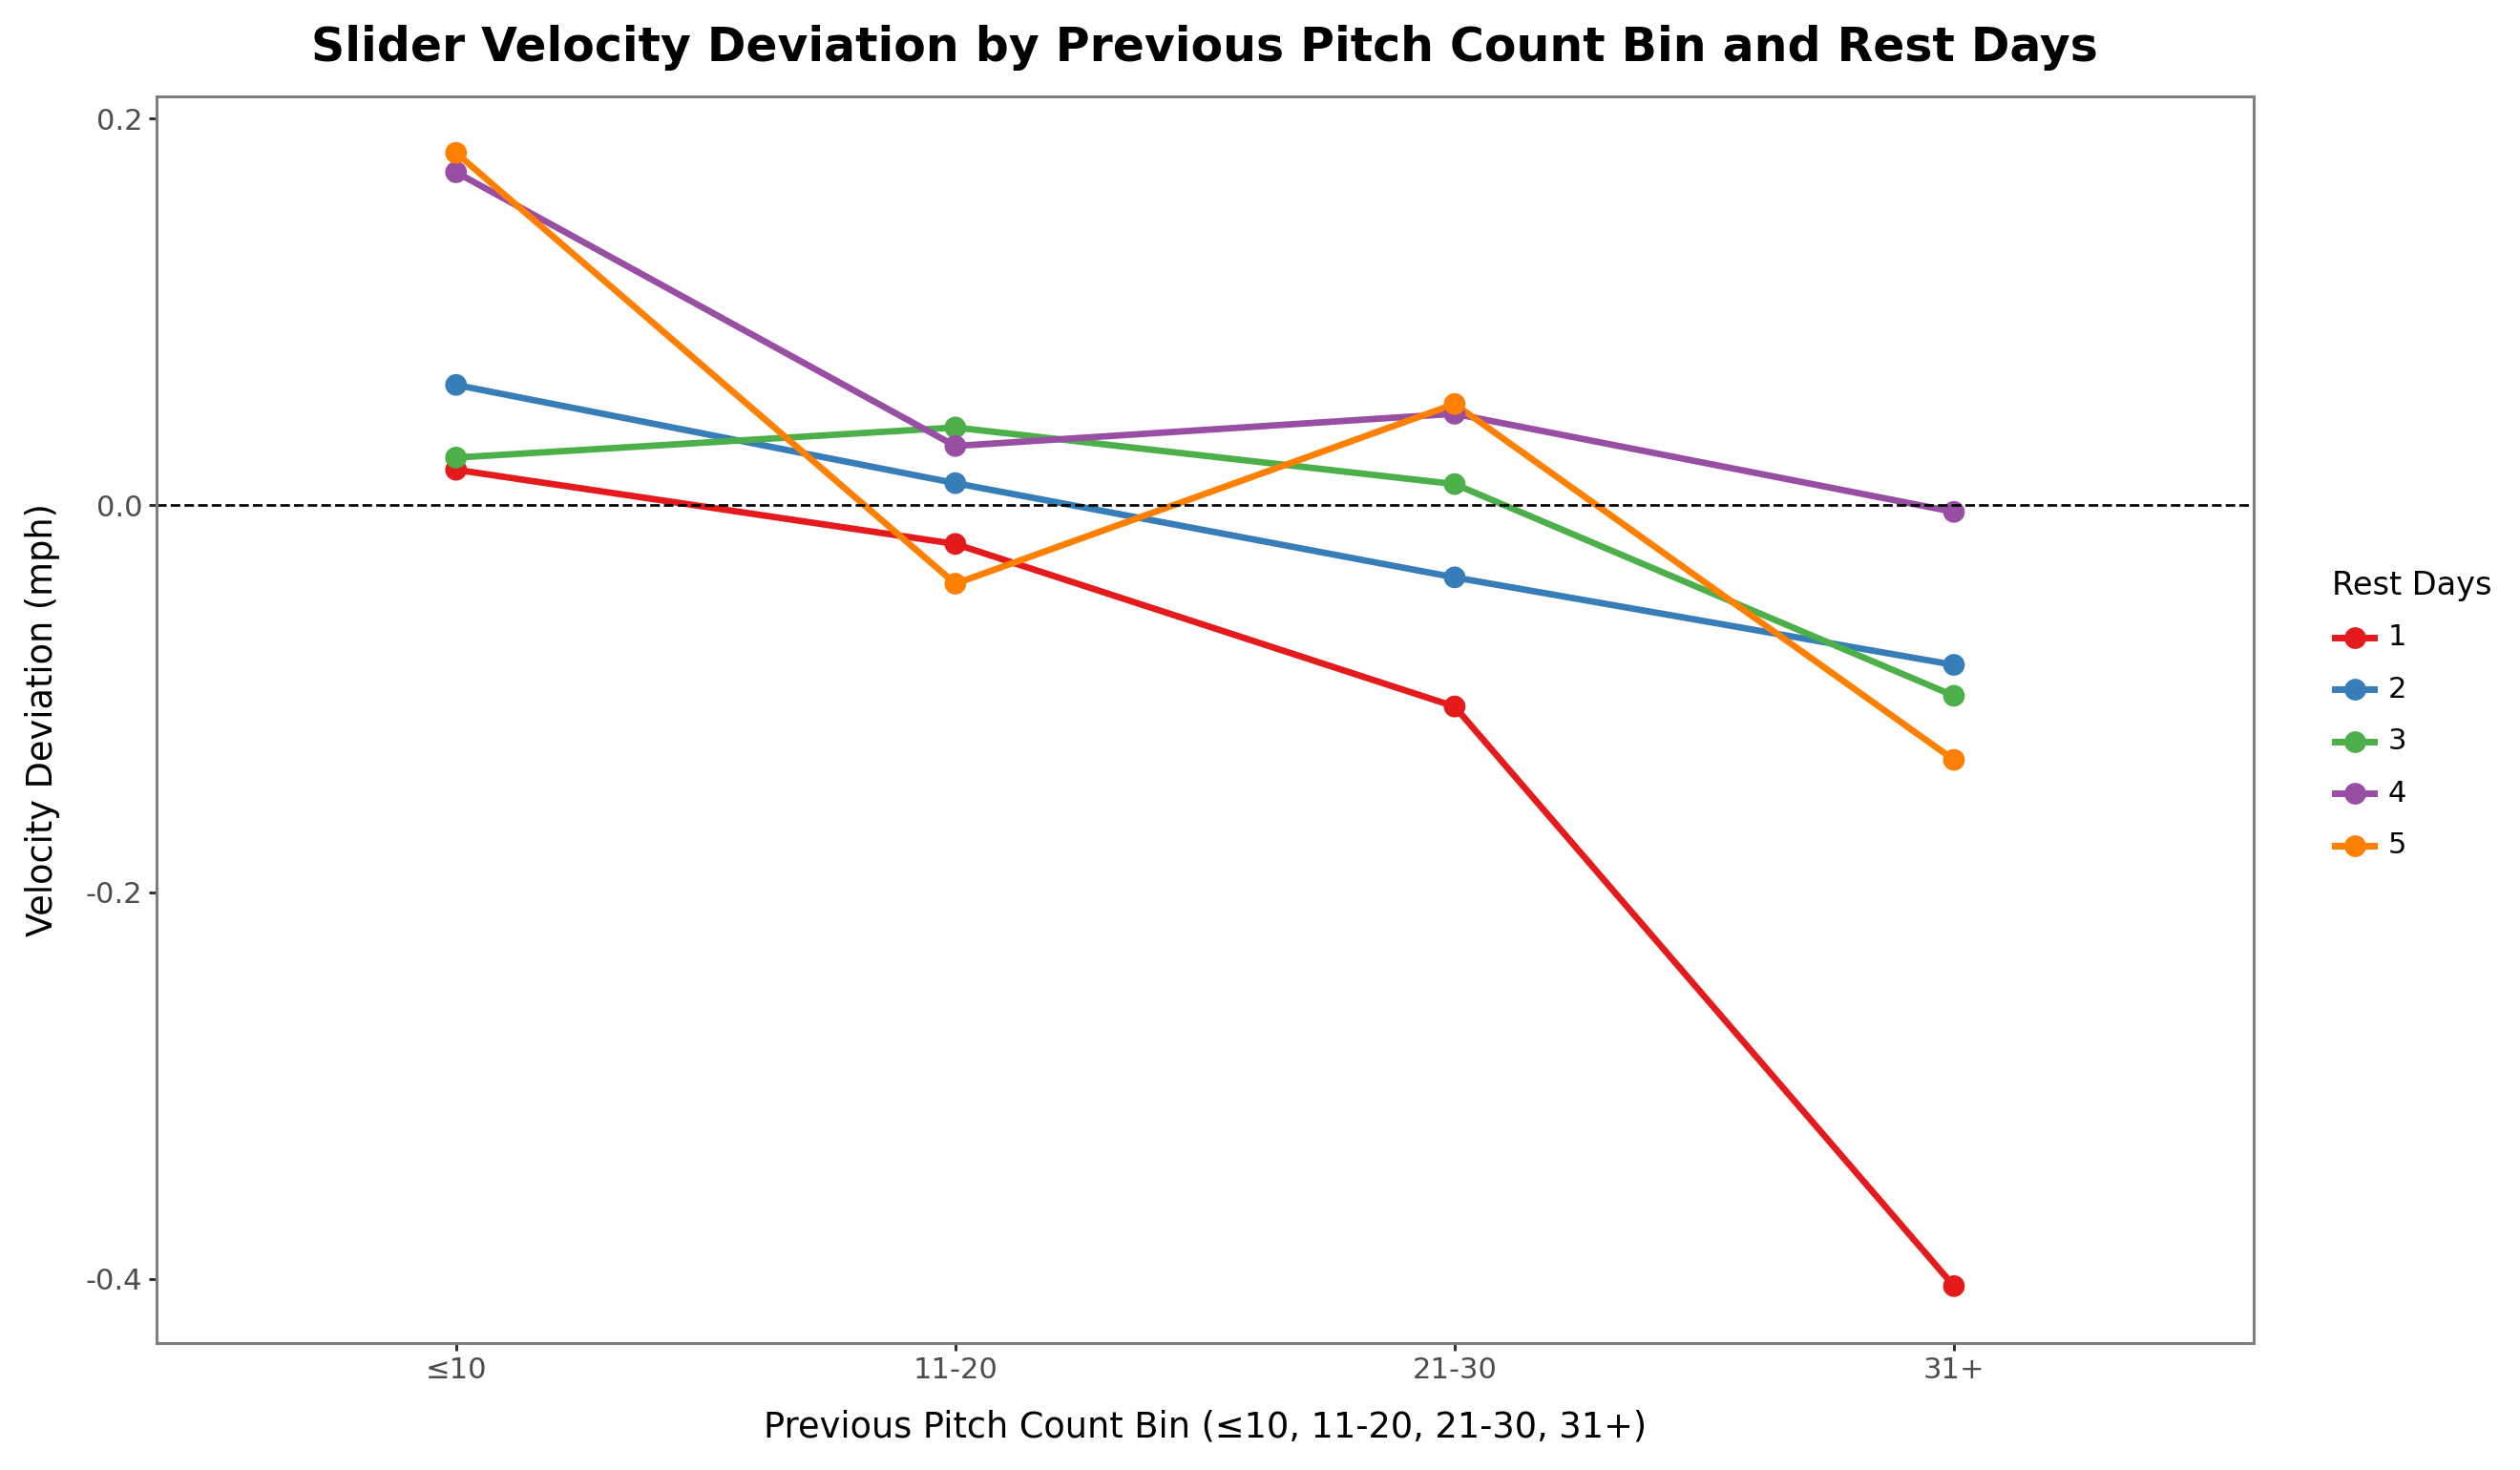

In [61]:
# Slider velocity: previous pitch-count bin x rest-day groups (1-5)
slider_velo_plot = (
    slider_outing_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "slider_velo_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "slider_velo_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("slider_velo_deviation").alias("avg_velo_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
slider_velo_plot["prev_pitch_bin"] = pd.Categorical(
    slider_velo_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
slider_velo_plot = slider_velo_plot.sort_values(["rest_days", "prev_pitch_bin"]).reset_index(drop=True)

(
    ggplot(
        slider_velo_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_velo_deviation",
            group="factor(rest_days)",
            color="factor(rest_days)",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_brewer(type="qual", palette="Set1")
    + labs(
        title="Slider Velocity Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Velocity Deviation (mph)",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white", color="white"),
        plot_background=element_rect(fill="white", color="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

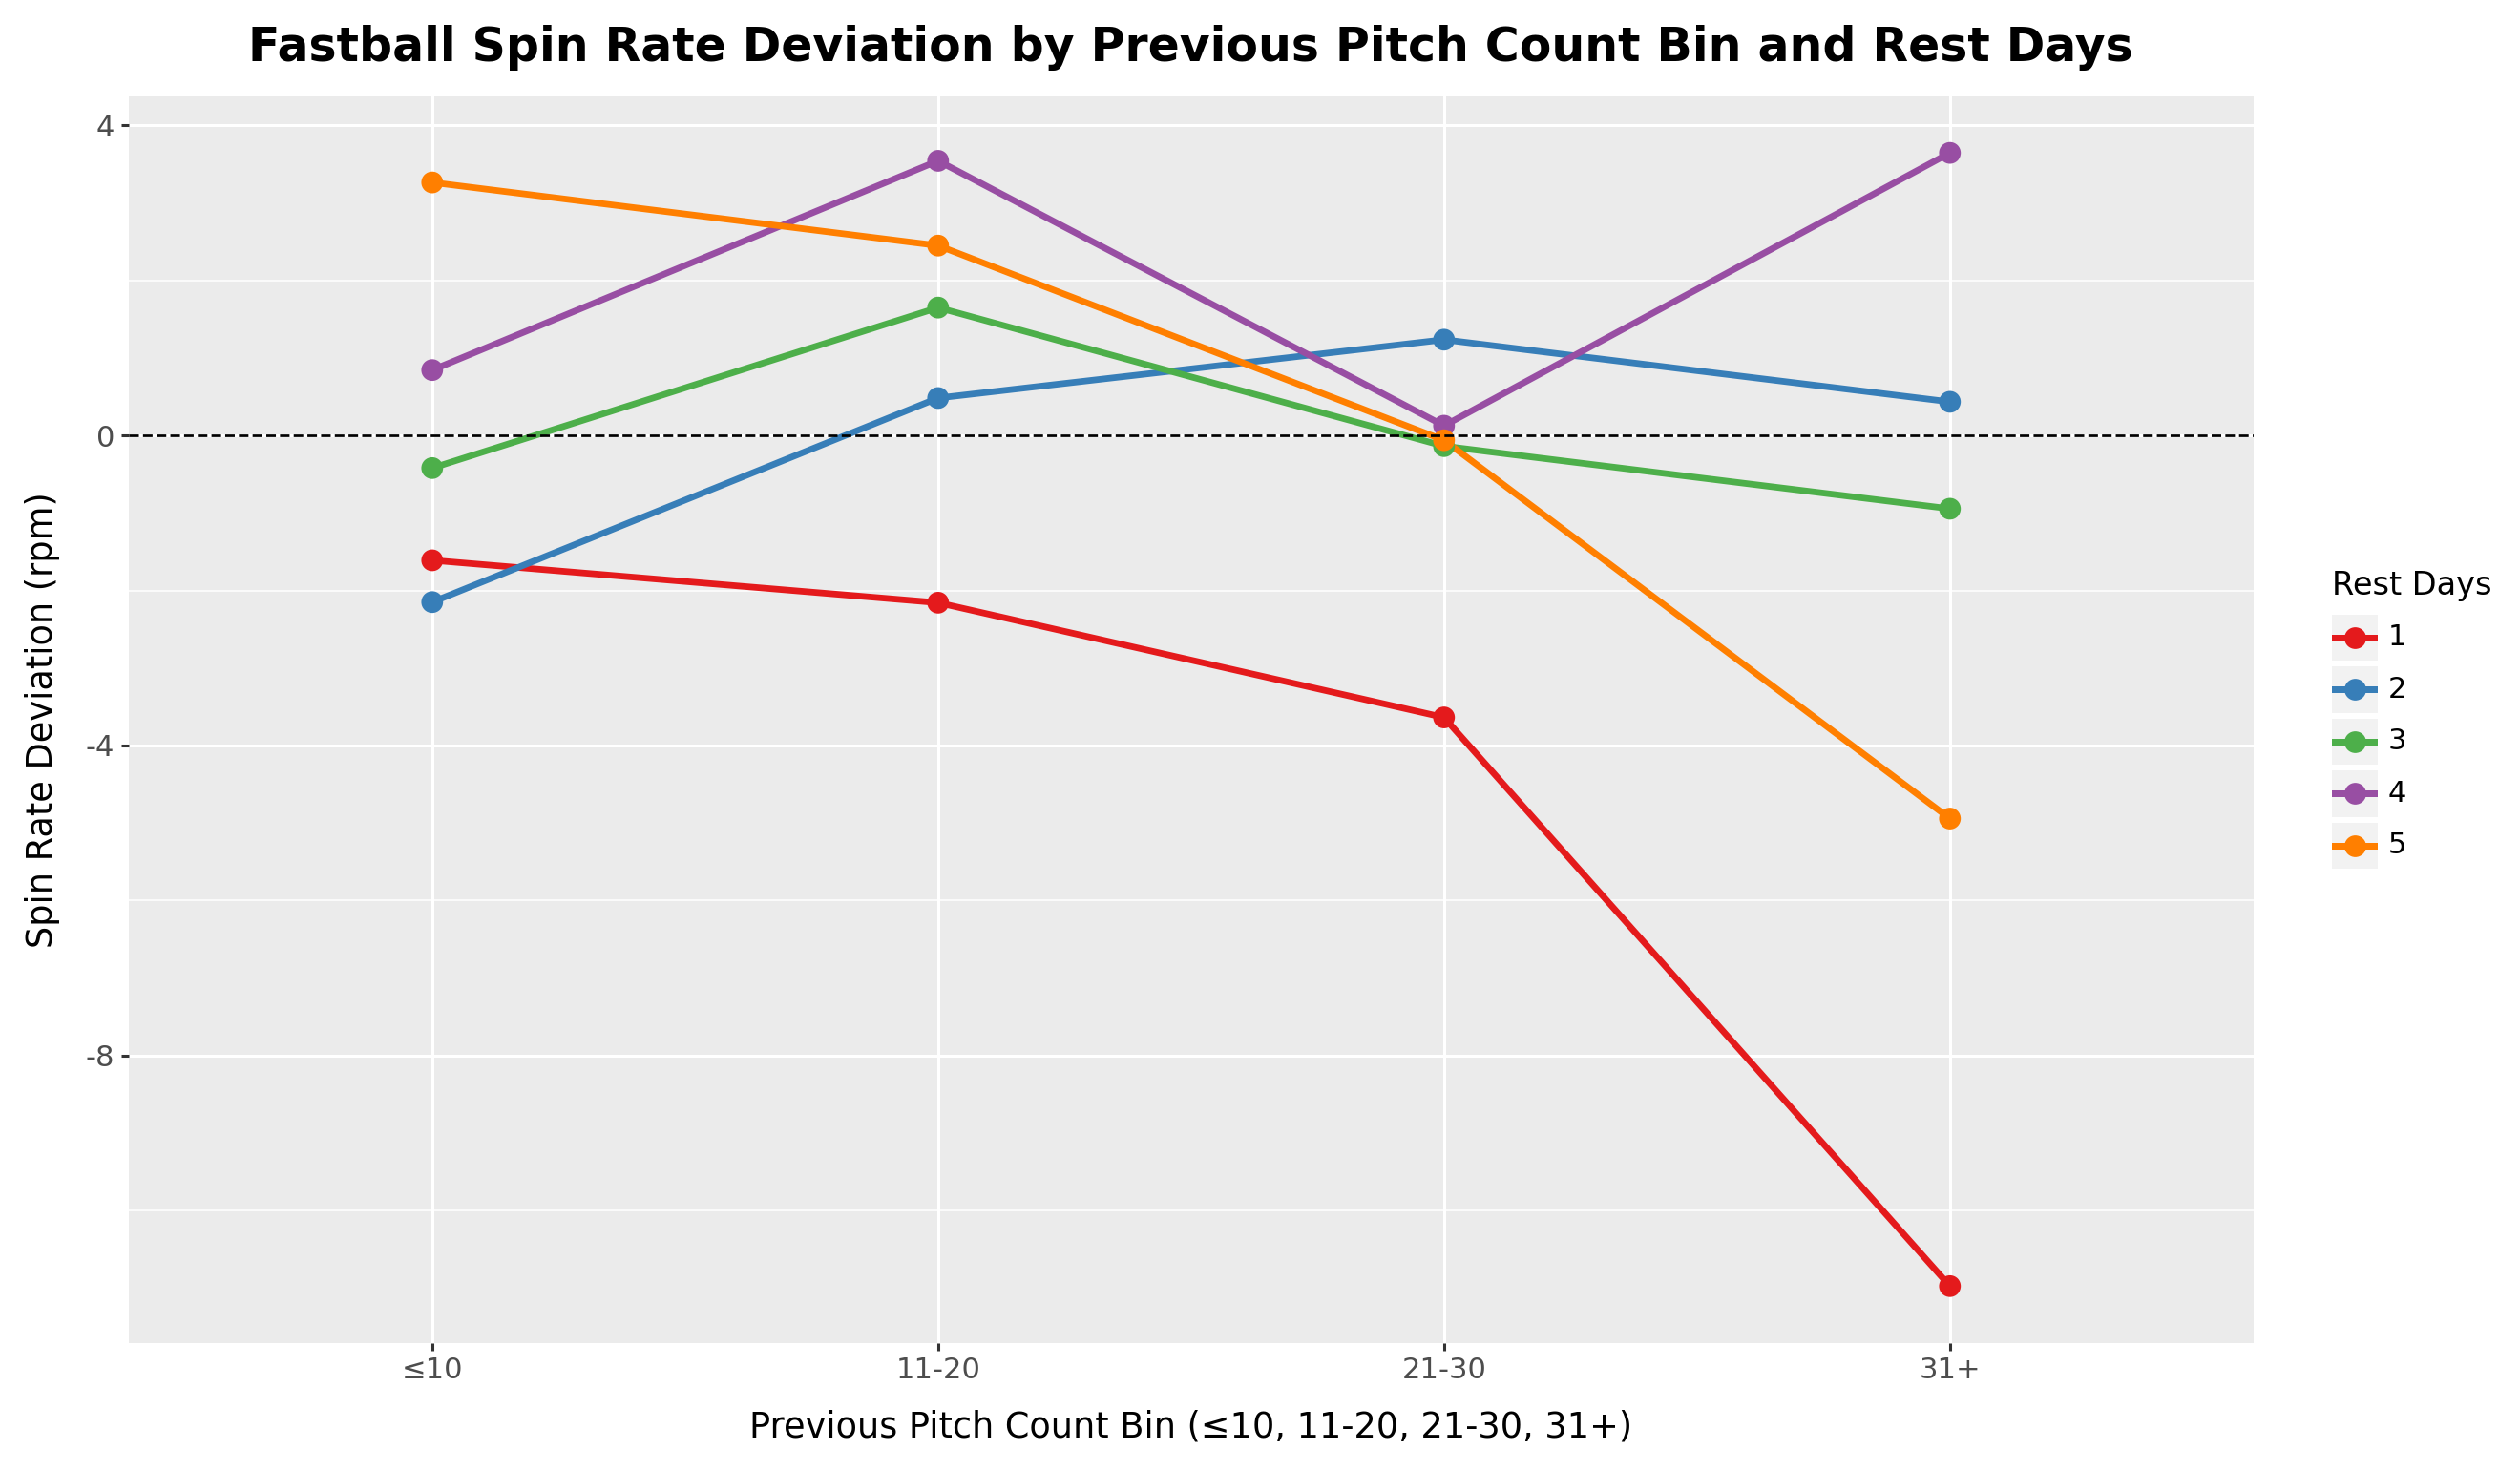

In [47]:
# Fastball spin rate: previous pitch-count bin x rest-day groups (1-5)
fb_spin_plot = (
    complete_outing_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "spin_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "spin_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("spin_deviation").alias("avg_spin_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
fb_spin_plot["prev_pitch_bin"] = pd.Categorical(
    fb_spin_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
fb_spin_plot = fb_spin_plot.sort_values(["rest_days", "prev_pitch_bin"])

(
    ggplot(
        fb_spin_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_spin_deviation",
            group="factor(rest_days)",
            color="factor(rest_days)",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_brewer(type="qual", palette="Set1")
    + labs(
        title="Fastball Spin Rate Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Spin Rate Deviation (rpm)",
        color="Rest Days",
    )
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
    )
)